## STEP 1 — IMPORTS & CONFIGURATION

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pyodbc
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {
    'primary': '#2C3E50',
    'churn': '#E74C3C',
    'no_churn': '#2980B9',
    'accent': '#27AE60',
    'light': '#ECF0F1',
    'gold': '#F39C12'
}

print("✅ Libraries imported successfully")

✅ Libraries imported successfully


## STEP 2 — LOADING DATA FROM SQL SERVER

In [2]:
conn = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=localhost\\SQLEXPRESS;'
    'DATABASE=CHURN;'
    'Trusted_Connection=yes;'
)

data  = pd.read_sql("SELECT * FROM dbo.ClientsTransactions", conn)
data1 = pd.read_sql("SELECT * FROM dbo.HistoriqueBlocageClient", conn)
data2 = pd.read_sql("SELECT * FROM dbo.Paiements", conn)
conn.close()

print(f"✅ ClientsTransactions  : {data.shape}")
print(f"✅ HistoriqueBlocage     : {data1.shape}")
print(f"✅ Paiements             : {data2.shape}")

✅ ClientsTransactions  : (3491728, 16)
✅ HistoriqueBlocage     : (14054, 5)
✅ Paiements             : (90119, 6)


In [3]:
print(data.head())

       ENTITE CODE_CLIENT  STAUT_CONVENTION DATE_INTEGRATION_CLIENT  \
0  HYDRAPHARM      H05218                 0              2019-02-13   
1  HYDRAPHARM      H05218                 0              2019-02-13   
2  HYDRAPHARM      H05218                 0              2019-02-13   
3  HYDRAPHARM      H05218                 0              2019-02-13   
4  HYDRAPHARM      H05218                 0              2019-02-13   

   CODE_WILAYA REGION                 ACTIVITE  DELAIS_PAIEMENT  \
0           16  ALGER  OFFICINE PHARMACEUTIQUE               75   
1           16  ALGER  OFFICINE PHARMACEUTIQUE               75   
2           16  ALGER  OFFICINE PHARMACEUTIQUE               75   
3           16  ALGER  OFFICINE PHARMACEUTIQUE               75   
4           16  ALGER  OFFICINE PHARMACEUTIQUE               75   

   LIMITE_CREDIT SEGMENT  NUM_TRANSACTION  date_trans TYPE_TRANS  \
0            0.0  Noyaux            76968  2025-03-17    FACTURE   
1            0.0  Noyaux          

In [4]:
print(data1.head())

   Entite CodeClient          Blocage                Date     MotifBlocage
0  ABCMED     A00001  Commande client 2024-02-19 14:17:13  Retard Paiement
1  ABCMED     A00003  Commande client 2024-05-07 08:37:01   Client Inactif
2  ABCMED     A00011  Commande client 2025-08-05 13:29:36  Retard Paiement
3  ABCMED     A00011              Non 2025-08-17 10:30:59                 
4  ABCMED     A00011  Commande client 2026-01-28 09:57:51  Retard Paiement


In [5]:
print(data2.head())

  ENTITE CODE_CLIENT     DATEIP TYPE_IP    MONTANT_IP    STATUT
0  GHMED      G00581 2025-08-31  Chèque  3.040026e+06  Encaissé
1  GHMED      G01026 2025-10-10  Chèque  9.946872e+06  Encaissé
2  GHMED      G03262 2025-06-26  Chèque  8.255257e+05  Encaissé
3  GHMED      G03015 2025-07-15  Chèque  1.176099e+06  Encaissé
4  GHMED      G03015 2025-08-10  Chèque  9.816453e+05  Encaissé


## Exploration ClientsTransactions

In [ ]:
print(f"Shape : {data.shape}")
print(f"\nColonnes : {data.columns.tolist()}")
print(f"\nUnique clients : {data['CODE_CLIENT'].nunique()}")
print(f"\nDate range : {data['date_trans'].min()} → {data['date_trans'].max()}")
print(f"\nTYPE_TRANS unique : {data['TYPE_TRANS'].unique()}")
print(f"\nACTIVITE unique : {data['ACTIVITE'].unique()}")
print(f"\nSEGMENT unique : {data['SEGMENT'].unique()}")
print(f"\nREGION unique : {data['REGION'].unique()}")
print(f"\nSTAUT_CONVENTION unique : {data['STAUT_CONVENTION'].unique()}")
print(f"\nSample :")
print(data.head(3))

Shape : (3491728, 16)

Colonnes : ['ENTITE', 'CODE_CLIENT', 'STAUT_CONVENTION', 'DATE_INTEGRATION_CLIENT', 'CODE_WILAYA', 'REGION', 'ACTIVITE', 'DELAIS_PAIEMENT', 'LIMITE_CREDIT', 'SEGMENT', 'NUM_TRANSACTION', 'date_trans', 'TYPE_TRANS', 'DATE_ECHEANCE', 'qte', 'ca']

Unique clients : 4415

Date range : 2024-03-01 → 2026-03-01

TYPE_TRANS unique : ['FACTURE' 'AVOIR']

ACTIVITE unique : ['OFFICINE PHARMACEUTIQUE' 'ETS DE SANTE PRIVE' 'ETS DISTRIBUTION EN GROS'
 'ETS DE SANTE PUBLIQUE' 'FILIALE DU GROUPE']

SEGMENT unique : ['Noyaux' 'CL-PARA' 'Partenaire' 'Négociateur' 'Filiale GHP' 'HOSPITALIER'
 '']

REGION unique : ['ALGER' 'OUEST' 'OUEST_HP' 'CENTRE' 'EST_HP' 'SUD' 'EST' '']

STAUT_CONVENTION unique : [0 1]

Sample :
       ENTITE CODE_CLIENT  STAUT_CONVENTION DATE_INTEGRATION_CLIENT  \
0  HYDRAPHARM      H05218                 0              2019-02-13   
1  HYDRAPHARM      H05218                 0              2019-02-13   
2  HYDRAPHARM      H05218                 0              

## Exploration HistoriqueBlocageClient 

In [ ]:
print(f"Shape : {data1.shape}")
print(f"\nColonnes : {data1.columns.tolist()}")
print(f"\nUnique clients : {data1['CodeClient'].nunique()}")
print(f"\nBlocage unique : {data1['Blocage'].unique()}")
print(f"\nMotifBlocage unique : {data1['MotifBlocage'].unique()}")
print(f"\nSample :")
print(data1.head(3))

Shape : (14054, 5)

Colonnes : ['Entite', 'CodeClient', 'Blocage', 'Date', 'MotifBlocage']

Unique clients : 3341

Blocage unique : ['Commande client' 'Non' 'Tout' 'Facture']

MotifBlocage unique : ['Retard Paiement' 'Client Inactif' '' 'Dossier Incomplet' 'Decés'
 'Fermeture' 'Commande spéciale' 'Blocage temporaire' 'Arrêt définitf'
 'Black List' "Changement d'adresse" "Doublons d'opérations"
 'Rejet non régularisée' 'Créance non régularisée'
 'Provision insuffisante' 'Compte cloturer']

Sample :
   Entite CodeClient          Blocage                Date     MotifBlocage
0  ABCMED     A00001  Commande client 2024-02-19 14:17:13  Retard Paiement
1  ABCMED     A00003  Commande client 2024-05-07 08:37:01   Client Inactif
2  ABCMED     A00011  Commande client 2025-08-05 13:29:36  Retard Paiement


## Exploration Paiements 

In [ ]:
print(f"Shape : {data2.shape}")
print(f"\nColonnes : {data2.columns.tolist()}")
print(f"\nUnique clients : {data2['CODE_CLIENT'].nunique()}")
print(f"\nTYPE_IP unique : {data2['TYPE_IP'].unique()}")
print(f"\nSTATUT unique : {data2['STATUT'].unique()}")
print(f"\nDate range : {data2['DATEIP'].min()} → {data2['DATEIP'].max()}")
print(f"\nSample :")
print(data2.head(3))

Shape : (90119, 6)

Colonnes : ['ENTITE', 'CODE_CLIENT', 'DATEIP', 'TYPE_IP', 'MONTANT_IP', 'STATUT']

Unique clients : 4443

TYPE_IP unique : ['Chèque' 'Virement' 'Traite' 'Avoir Financier' 'Espèce' 'Paiement TPE']

STATUT unique : ['Encaissé' 'Rejeté' 'En instance' 'Annulé']

Date range : 2024-03-01 00:00:00 → 2026-03-01 00:00:00

Sample :
  ENTITE CODE_CLIENT     DATEIP TYPE_IP    MONTANT_IP    STATUT
0  GHMED      G00581 2025-08-31  Chèque  3.040026e+06  Encaissé
1  GHMED      G01026 2025-10-10  Chèque  9.946872e+06  Encaissé
2  GHMED      G03262 2025-06-26  Chèque  8.255257e+05  Encaissé


## STEP 3 — DATA CLEANING & DATE CONVERSION

In [3]:
# Convert dates
data['date_trans']               = pd.to_datetime(data['date_trans'])
data['DATE_INTEGRATION_CLIENT']  = pd.to_datetime(data['DATE_INTEGRATION_CLIENT'])
data['DATE_ECHEANCE']            = pd.to_datetime(data['DATE_ECHEANCE'])
data1['Date']                    = pd.to_datetime(data1['Date'])
data2['DATEIP']                  = pd.to_datetime(data2['DATEIP'])

# Keep only FACTURE (exclude AVOIR which are credit notes)
data_invoices = data[data['TYPE_TRANS'] == 'FACTURE'].copy()
data_avoirs   = data[data['TYPE_TRANS'] == 'AVOIR'].copy()

# Reference date = last transaction date
reference_date = pd.Timestamp('2026-03-01')

print(f"Total transactions     : {data.shape[0]:,}")
print(f"Invoices (FACTURE)     : {data_invoices.shape[0]:,}")
print(f"Credit notes (AVOIR)   : {data_avoirs.shape[0]:,}")
print(f"Unique clients         : {data['CODE_CLIENT'].nunique():,}")
print(f"Reference date         : {reference_date.date()}")
print(f"Date range             : {data['date_trans'].min().date()} → {data['date_trans'].max().date()}")
print(f"\nMissing values (transactions) : {data.isnull().sum().sum()}")
print(f"Missing values (blocages)     : {data1.isnull().sum().sum()}")
print(f"Missing values (paiements)    : {data2.isnull().sum().sum()}")

Total transactions     : 3,491,728
Invoices (FACTURE)     : 3,415,317
Credit notes (AVOIR)   : 76,411
Unique clients         : 4,415
Reference date         : 2026-03-01
Date range             : 2024-03-01 → 2026-03-01

Missing values (transactions) : 0
Missing values (blocages)     : 0
Missing values (paiements)    : 0


## STEP 4 — FEATURE ENGINEERING
### Build one row per client with all predictive features

In [4]:
# ---- BASE CLIENT INFO (one row per client) ----
client_info = data.groupby('CODE_CLIENT').agg(
    ENTITE                  = ('ENTITE',                  'first'),
    STAUT_CONVENTION        = ('STAUT_CONVENTION',        'first'),
    DATE_INTEGRATION_CLIENT = ('DATE_INTEGRATION_CLIENT', 'first'),
    CODE_WILAYA             = ('CODE_WILAYA',             'first'),
    REGION                  = ('REGION',                  'first'),
    ACTIVITE                = ('ACTIVITE',                'first'),
    DELAIS_PAIEMENT         = ('DELAIS_PAIEMENT',         'first'),
    LIMITE_CREDIT           = ('LIMITE_CREDIT',           'first'),
    SEGMENT                 = ('SEGMENT',                 'first'),
).reset_index()

# ---- RECENCY ----
last_order = data_invoices.groupby('CODE_CLIENT')['date_trans'].max().reset_index()
last_order.columns = ['CODE_CLIENT', 'Last_Order_Date']
last_order['Recency_Days'] = (reference_date - last_order['Last_Order_Date']).dt.days

# ---- FREQUENCY ----
# Total number of invoices
freq_total = data_invoices.groupby('CODE_CLIENT')['NUM_TRANSACTION'].nunique().reset_index()
freq_total.columns = ['CODE_CLIENT', 'Frequency_Total']

# Frequency last 6 months
cutoff_6m = reference_date - pd.DateOffset(months=6)
freq_6m = data_invoices[data_invoices['date_trans'] >= cutoff_6m].groupby('CODE_CLIENT')['NUM_TRANSACTION'].nunique().reset_index()
freq_6m.columns = ['CODE_CLIENT', 'Frequency_6months']

# ---- MONETARY ----
monetary = data_invoices.groupby('CODE_CLIENT').agg(
    Total_Revenue_DA = ('ca', 'sum'),
    Avg_Revenue_per_Transaction = ('ca', 'mean'),
    Total_Quantity   = ('qte', 'sum'),
).reset_index()

# Revenue Period N (last 6 months) vs N-1 (previous 6 months)
cutoff_n1 = reference_date - pd.DateOffset(months=12)
rev_n  = data_invoices[data_invoices['date_trans'] >= cutoff_6m].groupby('CODE_CLIENT')['ca'].sum().reset_index()
rev_n.columns  = ['CODE_CLIENT', 'Revenue_Period_N_DA']
rev_n1 = data_invoices[(data_invoices['date_trans'] >= cutoff_n1) & (data_invoices['date_trans'] < cutoff_6m)].groupby('CODE_CLIENT')['ca'].sum().reset_index()
rev_n1.columns = ['CODE_CLIENT', 'Revenue_Period_N1_DA']

# ---- REGULARITY ----
# Number of distinct months with at least one order / total months in portfolio
client_months = data_invoices.groupby('CODE_CLIENT').apply(
    lambda x: x['date_trans'].dt.to_period('M').nunique()
).reset_index()
client_months.columns = ['CODE_CLIENT', 'Active_Months']

# Total portfolio duration in months
portfolio_duration = data_invoices.groupby('CODE_CLIENT')['date_trans'].agg(
    lambda x: max(1, (x.max() - x.min()).days // 30)
).reset_index()
portfolio_duration.columns = ['CODE_CLIENT', 'Portfolio_Duration_Months']

reg = client_months.merge(portfolio_duration, on='CODE_CLIENT')
reg['Regularity_Rate'] = (reg['Active_Months'] / reg['Portfolio_Duration_Months']).clip(0, 1).round(3)

# ---- AVG DAYS BETWEEN ORDERS ----
def avg_days_between(dates):
    dates_sorted = sorted(dates)
    if len(dates_sorted) < 2:
        return 0
    diffs = [(dates_sorted[i+1] - dates_sorted[i]).days for i in range(len(dates_sorted)-1)]
    return round(np.mean(diffs), 1)

avg_between = data_invoices.groupby('CODE_CLIENT')['date_trans'].apply(avg_days_between).reset_index()
avg_between.columns = ['CODE_CLIENT', 'Avg_Days_Between_Orders']

# ---- PRODUCT DIVERSITY ----
product_div = data_invoices.groupby('CODE_CLIENT').agg(
    Nb_Distinct_Products      = ('NUM_TRANSACTION', 'nunique'),
    Avg_Order_Lines           = ('qte', 'mean'),
    Nb_Cancelled_Orders       = ('NUM_TRANSACTION', 'count'),  # will refine below
).reset_index()

# Cancelled/returned = AVOIR transactions
avoirs_per_client = data_avoirs.groupby('CODE_CLIENT')['NUM_TRANSACTION'].nunique().reset_index()
avoirs_per_client.columns = ['CODE_CLIENT', 'Nb_Cancelled_Returned_Orders']

# ---- BLOCAGES ---- 

motifs_prelitigation = [
    'Black List', 'Créance non régularisée', 'Rejet non régularisée',
    'Provision insuffisante', 'Compte cloturer', 'Arrêt définitf'
]

blocages_actifs = data1[data1['Blocage'] != 'Non'].copy()

blocages = blocages_actifs.groupby('CodeClient').agg(
    Nb_Blockages   = ('Blocage', 'count'),
    Pre_Litigation = ('MotifBlocage', lambda x: 1 if any(
        m in motifs_prelitigation for m in x.values) else 0),
).reset_index()
blocages.columns = ['CODE_CLIENT', 'Nb_Blockages', 'Pre_Litigation']

# ---- PAIEMENTS ---- 

pay_stats = data2.groupby('CODE_CLIENT').agg(
    Nb_Late_Payments    = ('STATUT', lambda x: (x == 'Rejeté').sum()),
    Nb_Pending_Payments = ('STATUT', lambda x: (x == 'En instance').sum()),
    Nb_Payments_Total   = ('STATUT', 'count'),
    Payment_Method      = ('TYPE_IP', lambda x: x.mode()[0] if len(x) > 0 else 'Unknown'),
).reset_index()

# Outstanding balance = paiements En instance + Rejeté
outstanding = data2[data2['STATUT'].isin(['En instance', 'Rejeté'])].groupby(
    'CODE_CLIENT')['MONTANT_IP'].sum().reset_index()
outstanding.columns = ['CODE_CLIENT', 'Outstanding_Balance_DA']
# Payment delay per client
pay_stats = data2.groupby('CODE_CLIENT').agg(
    Nb_Late_Payments  = ('STATUT', lambda x: (x == 'En retard').sum() if 'En retard' in x.values else 0),
    Nb_Payments_Total = ('STATUT', 'count'),
    Total_Paid        = ('MONTANT_IP', 'sum'),
    Payment_Method    = ('TYPE_IP', lambda x: x.mode()[0] if len(x) > 0 else 'Unknown'),
).reset_index()

# ---- AVERAGE PAYMENT DELAY ----
# Use DELAIS_PAIEMENT from client info as proxy for contractual delay
# Compute actual delay from DATEIP vs DATE_ECHEANCE
echeance_per_client = data[['CODE_CLIENT','DATE_ECHEANCE']].dropna()
paiement_dates = data2[['CODE_CLIENT','DATEIP']].dropna()

delay_df = echeance_per_client.merge(paiement_dates, on='CODE_CLIENT', how='inner')
delay_df['Payment_Delay'] = (delay_df['DATEIP'] - delay_df['DATE_ECHEANCE']).dt.days
delay_df['Payment_Delay'] = delay_df['Payment_Delay'].clip(lower=0)  # negative = paid early
avg_delay = delay_df.groupby('CODE_CLIENT')['Payment_Delay'].mean().round(1).reset_index()
avg_delay.columns = ['CODE_CLIENT', 'Avg_Payment_Delay_Days']

# Outstanding balance per client
outstanding = data2[data2['STATUT'] != 'Encaissé'].groupby('CODE_CLIENT')['MONTANT_IP'].sum().reset_index()
outstanding.columns = ['CODE_CLIENT', 'Outstanding_Balance_DA']

print("✅ All features computed — merging...")

✅ All features computed — merging...


##  STEP 5 — MERGE ALL FEATURES + MISSING VALUES HANDLING

In [5]:
df = client_info.copy()

# Merge all computed features
df = df.merge(last_order,      on='CODE_CLIENT', how='left')
df = df.merge(freq_total,      on='CODE_CLIENT', how='left')
df = df.merge(freq_6m,         on='CODE_CLIENT', how='left')
df = df.merge(monetary,        on='CODE_CLIENT', how='left')
df = df.merge(rev_n,           on='CODE_CLIENT', how='left')
df = df.merge(rev_n1,          on='CODE_CLIENT', how='left')
df = df.merge(reg[['CODE_CLIENT','Regularity_Rate']], on='CODE_CLIENT', how='left')
df = df.merge(avg_between,     on='CODE_CLIENT', how='left')
df = df.merge(product_div[['CODE_CLIENT','Nb_Distinct_Products','Avg_Order_Lines']], on='CODE_CLIENT', how='left')
df = df.merge(avoirs_per_client, on='CODE_CLIENT', how='left')
df = df.merge(blocages,        on='CODE_CLIENT', how='left')
df = df.merge(pay_stats,       on='CODE_CLIENT', how='left')
df = df.merge(avg_delay,       on='CODE_CLIENT', how='left')
df = df.merge(outstanding,     on='CODE_CLIENT', how='left')

print(f"✅ Merged dataset shape : {df.shape}")
print(f"Unique clients         : {df['CODE_CLIENT'].nunique()}")

print("\nMISSING VALUES ANALYSIS BEFORE TREATMENT")
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0]
print(missing_before)

# ── GROUP 1: 76 clients with NO FACTURE transactions ──────
# These clients exist in the DB but never placed an order
# → They are by definition churned (or never activated)
# → Fill transaction-based features with 0 / max recency

no_invoice_mask = df['Recency_Days'].isnull()
print(f"\nClients with NO invoice (FACTURE) : {no_invoice_mask.sum()}")
print("→ Treated as maximum recency (fully churned/inactive)")

# Recency = max recency of the whole dataset + 1 (worst case)
max_recency = df['Recency_Days'].max()

df.loc[no_invoice_mask, 'Last_Order_Date']              = pd.NaT
df.loc[no_invoice_mask, 'Recency_Days']                 = max_recency + 1
df.loc[no_invoice_mask, 'Frequency_Total']              = 0
df.loc[no_invoice_mask, 'Frequency_6months']            = 0
df.loc[no_invoice_mask, 'Total_Revenue_DA']             = 0
df.loc[no_invoice_mask, 'Avg_Revenue_per_Transaction']  = 0
df.loc[no_invoice_mask, 'Total_Quantity']               = 0
df.loc[no_invoice_mask, 'Regularity_Rate']              = 0
df.loc[no_invoice_mask, 'Avg_Days_Between_Orders']      = 0
df.loc[no_invoice_mask, 'Nb_Distinct_Products']         = 0
df.loc[no_invoice_mask, 'Avg_Order_Lines']              = 0

# ── GROUP 2: Standard zero-fills ──────────────────────────
# Clients with no blocage history
df['Nb_Blockages']                  = df['Nb_Blockages'].fillna(0)
df['Pre_Litigation']                = df['Pre_Litigation'].fillna(0)

# Clients with no AVOIR (returns/credit notes)
df['Nb_Cancelled_Returned_Orders']  = df['Nb_Cancelled_Returned_Orders'].fillna(0)

# Revenue periods
df['Revenue_Period_N_DA']           = df['Revenue_Period_N_DA'].fillna(0)
df['Revenue_Period_N1_DA']          = df['Revenue_Period_N1_DA'].fillna(0)

# ── GROUP 3: 239 clients with NO payment records ──────────
# These clients ordered but never had a payment registered
# → Not necessarily churned, but payment behavior unknown

no_payment_mask = df['Nb_Payments_Total'].isnull()
print(f"\nClients with NO payment record : {no_payment_mask.sum()}")
print("→ Payment features filled with 0 / contractual delay")

df.loc[no_payment_mask, 'Nb_Payments_Total']      = 0
df.loc[no_payment_mask, 'Total_Paid']             = 0
df.loc[no_payment_mask, 'Nb_Late_Payments']       = df.loc[no_payment_mask, 'Nb_Late_Payments'].fillna(0)
df.loc[no_payment_mask, 'Payment_Method']         = 'Unknown'

# Average payment delay: use contractual delay (DELAIS_PAIEMENT) as proxy
df['Avg_Payment_Delay_Days'] = df['Avg_Payment_Delay_Days'].fillna(df['DELAIS_PAIEMENT'])

# Outstanding balance
df['Outstanding_Balance_DA']  = df['Outstanding_Balance_DA'].fillna(0)

# ── Final check ───────────────────────────────────────────
print("\n" + "=" * 60)
print("MISSING VALUES AFTER TREATMENT")
print("=" * 60)
remaining_missing = df.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) == 0:
    print("✅ No missing values remaining")
else:
    print("⚠️  Still missing :")
    print(remaining_missing)
    # Fallback: fill any remaining numeric NaN with median
    num_cols = df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if df[col].isnull().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f"  → {col} filled with median ({median_val:.2f})")

print(f"\n✅ Final dataset shape  : {df.shape}")
print(f"   Unique clients       : {df['CODE_CLIENT'].nunique():,}")
print(f"\nClient breakdown :")
print(f"  With invoices         : {(~no_invoice_mask).sum():,}")
print(f"  Without invoices      : {no_invoice_mask.sum():,}  (forced churn)")
print(f"  Without payment data  : {no_payment_mask.sum():,}  (payment unknown)")

✅ Merged dataset shape : (4415, 32)
Unique clients         : 4415

MISSING VALUES ANALYSIS BEFORE TREATMENT
Last_Order_Date                   76
Recency_Days                      76
Frequency_Total                   76
Frequency_6months                824
Total_Revenue_DA                  76
Avg_Revenue_per_Transaction       76
Total_Quantity                    76
Revenue_Period_N_DA              824
Revenue_Period_N1_DA             992
Regularity_Rate                   76
Avg_Days_Between_Orders           76
Nb_Distinct_Products              76
Avg_Order_Lines                   76
Nb_Cancelled_Returned_Orders     579
Nb_Blockages                    2180
Pre_Litigation                  2180
Nb_Late_Payments                 239
Nb_Payments_Total                239
Total_Paid                       239
Payment_Method                   239
Avg_Payment_Delay_Days           239
Outstanding_Balance_DA          2455
dtype: int64

Clients with NO invoice (FACTURE) : 76
→ Treated as maximum rece

## STEP 6 — DEFINE CHURN LABEL
### Churn = 1 if Recency_Days >= 90 (3 months of inactivity)

In [6]:
CHURN_THRESHOLD = 90  # days of inactivity

df['Churn'] = (df['Recency_Days'] >= CHURN_THRESHOLD).astype(int)

print(f"Churn threshold : {CHURN_THRESHOLD} days of inactivity")
print(f"\nChurn distribution :")
print(f"  Non-Churners (0) : {(df['Churn']==0).sum():,} ({(df['Churn']==0).mean()*100:.1f}%)")
print(f"  Churners     (1) : {(df['Churn']==1).sum():,} ({(df['Churn']==1).mean()*100:.1f}%)")

print(f"\nChurn by ACTIVITE :")
print((df.groupby('ACTIVITE')['Churn'].mean()*100).round(1).sort_values(ascending=False))

print(f"\nChurn by REGION :")
print((df.groupby('REGION')['Churn'].mean()*100).round(1).sort_values(ascending=False))

print(f"\nChurn by STAUT_CONVENTION :")
print((df.groupby('STAUT_CONVENTION')['Churn'].mean()*100).round(1))

Churn threshold : 90 days of inactivity

Churn distribution :
  Non-Churners (0) : 3,434 (77.8%)
  Churners     (1) : 981 (22.2%)

Churn by ACTIVITE :
ACTIVITE
ETS DE SANTE PUBLIQUE       46.7
OFFICINE PHARMACEUTIQUE     22.6
ETS DE SANTE PRIVE          19.3
ETS DISTRIBUTION EN GROS     0.0
FILIALE DU GROUPE            0.0
Name: Churn, dtype: float64

Churn by REGION :
REGION
SUD         29.5
EST_HP      26.3
EST         24.0
OUEST_HP    23.7
OUEST       20.9
ALGER       20.5
CENTRE      19.3
             0.0
Name: Churn, dtype: float64

Churn by STAUT_CONVENTION :
STAUT_CONVENTION
0    22.7
1     8.4
Name: Churn, dtype: float64


## STEP 7 — ADDITIONAL FEATURE ENGINEERING

In [7]:
# Client seniority in months
df['Client_Seniority_Months'] = (
    (reference_date - df['DATE_INTEGRATION_CLIENT']).dt.days / 30.44
).round(1)

# Revenue evolution %
df['Revenue_Evolution_Pct'] = np.where(
    df['Revenue_Period_N1_DA'] > 0,
    ((df['Revenue_Period_N_DA'] - df['Revenue_Period_N1_DA']) / df['Revenue_Period_N1_DA'] * 100).round(2),
    0
)

# RFM Scores
df['R_Score'] = pd.qcut(df['Recency_Days'].rank(method='first'), q=5, labels=[5,4,3,2,1]).astype(int)
df['F_Score'] = pd.qcut(df['Frequency_Total'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
df['M_Score'] = pd.qcut(df['Total_Revenue_DA'].rank(method='first'), q=5, labels=[1,2,3,4,5]).astype(int)
df['RFM_Score'] = df['R_Score'] + df['F_Score'] + df['M_Score']

# Discounts proxy (AVOIR / FACTURE revenue ratio)
avoir_ca = data_avoirs.groupby('CODE_CLIENT')['ca'].sum().abs().reset_index()
avoir_ca.columns = ['CODE_CLIENT', 'Total_Avoir_DA']
df = df.merge(avoir_ca, on='CODE_CLIENT', how='left')
df['Total_Avoir_DA'].fillna(0, inplace=True)
df['Discount_Rate'] = np.where(
    df['Total_Revenue_DA'] > 0,
    (df['Total_Avoir_DA'] / df['Total_Revenue_DA']).clip(0, 1).round(3),
    0
)

print(f"✅ Client_Seniority_Months — Mean : {df['Client_Seniority_Months'].mean():.1f} months")
print(f"✅ Revenue_Evolution_Pct  — Churners mean    : {df[df['Churn']==1]['Revenue_Evolution_Pct'].mean():.1f}%")
print(f"                          — Non-churners mean: {df[df['Churn']==0]['Revenue_Evolution_Pct'].mean():.1f}%")
print(f"✅ RFM_Score              — Churners mean    : {df[df['Churn']==1]['RFM_Score'].mean():.2f}")
print(f"                          — Non-churners mean: {df[df['Churn']==0]['RFM_Score'].mean():.2f}")

✅ Client_Seniority_Months — Mean : 95.3 months
✅ Revenue_Evolution_Pct  — Churners mean    : -33.5%
                          — Non-churners mean: 106.7%
✅ RFM_Score              — Churners mean    : 4.64
                          — Non-churners mean: 10.25


In [15]:
print(df.head())

  CODE_CLIENT  ENTITE  STAUT_CONVENTION DATE_INTEGRATION_CLIENT  CODE_WILAYA  \
0      101369  DEFMED                 0              2011-07-17           17   
1         126  DEFMED                 0              2015-02-11           31   
2         128  DEFMED                 0              2015-02-16           13   
3         129  DEFMED                 0              2015-02-23           48   
4         130  DEFMED                 0              2015-02-23           22   

   REGION                 ACTIVITE  DELAIS_PAIEMENT  LIMITE_CREDIT  \
0  EST_HP  OFFICINE PHARMACEUTIQUE              120            0.0   
1   OUEST  OFFICINE PHARMACEUTIQUE               90      3500000.0   
2   OUEST  OFFICINE PHARMACEUTIQUE               45            0.0   
3   OUEST  OFFICINE PHARMACEUTIQUE               60      2000000.0   
4   OUEST  OFFICINE PHARMACEUTIQUE               60      5000000.0   

      SEGMENT  ... Outstanding_Balance_DA  Churn  Client_Seniority_Months  \
0  Partenaire  ...   

## STEP 8 — EDA VISUALIZATIONS
### Churn Distribution

TARGET VARIABLE DISTRIBUTION
Non-Churners (0) : 3,434 clients (77.8%)
Churners     (1) : 981 clients (22.2%)


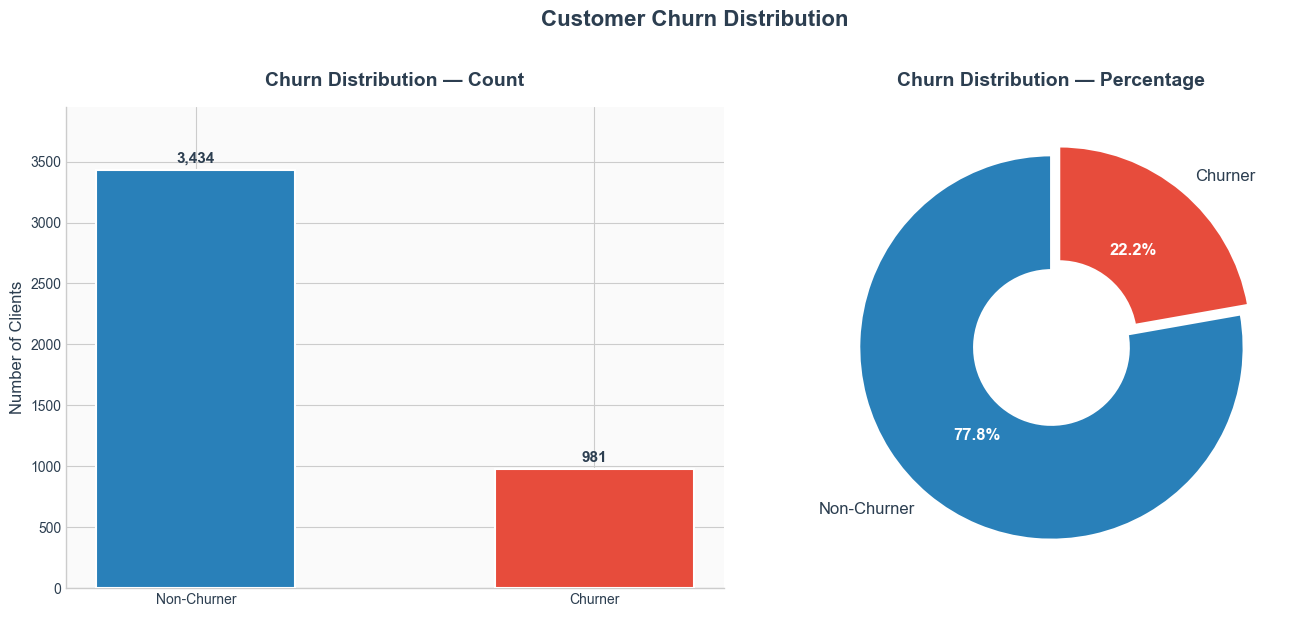

✅ Figure saved : churn_distribution.png


In [46]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
print(f"Non-Churners (0) : {churn_counts[0]:,} clients ({churn_pct[0]:.1f}%)")
print(f"Churners     (1) : {churn_counts[1]:,} clients ({churn_pct[1]:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

# Bar chart
bars = axes[0].bar(
    ['Non-Churner', 'Churner'],
    churn_counts.values,
    color=[COLORS['no_churn'], COLORS['churn']],
    edgecolor='white', linewidth=1.5,
    width=0.5, zorder=3
)
axes[0].set_title('Churn Distribution — Count',
                   fontsize=14, fontweight='bold',
                   pad=15, color=COLORS['primary'])
axes[0].set_ylabel('Number of Clients', fontsize=12, color=COLORS['primary'])
axes[0].set_facecolor('#FAFAFA')
axes[0].tick_params(colors=COLORS['primary'])
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_ylim(0, churn_counts.max() * 1.15)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 30,
                f'{val:,}',
                ha='center', va='bottom',
                fontsize=11, fontweight='bold',
                color=COLORS['primary'])

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values,
    labels=['Non-Churner', 'Churner'],
    autopct='%1.1f%%',
    colors=[COLORS['no_churn'], COLORS['churn']],
    startangle=90,
    explode=(0, 0.06),
    wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2),
    textprops={'fontsize': 12, 'color': COLORS['primary']}
)
for autotext in autotexts:
    autotext.set_fontsize(12)
    autotext.set_fontweight('bold')
    autotext.set_color('white')
axes[1].set_title('Churn Distribution — Percentage',
                   fontsize=14, fontweight='bold',
                   pad=15, color=COLORS['primary'])
axes[1].set_facecolor('white')

plt.suptitle('Customer Churn Distribution',
             fontsize=16, fontweight='bold',
             color=COLORS['primary'], y=1.02)
plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=200, bbox_inches='tight',
            facecolor='white')
plt.show()
print("✅ Figure saved : churn_distribution.png")

### Churn by ACTIVITE (Client Type)

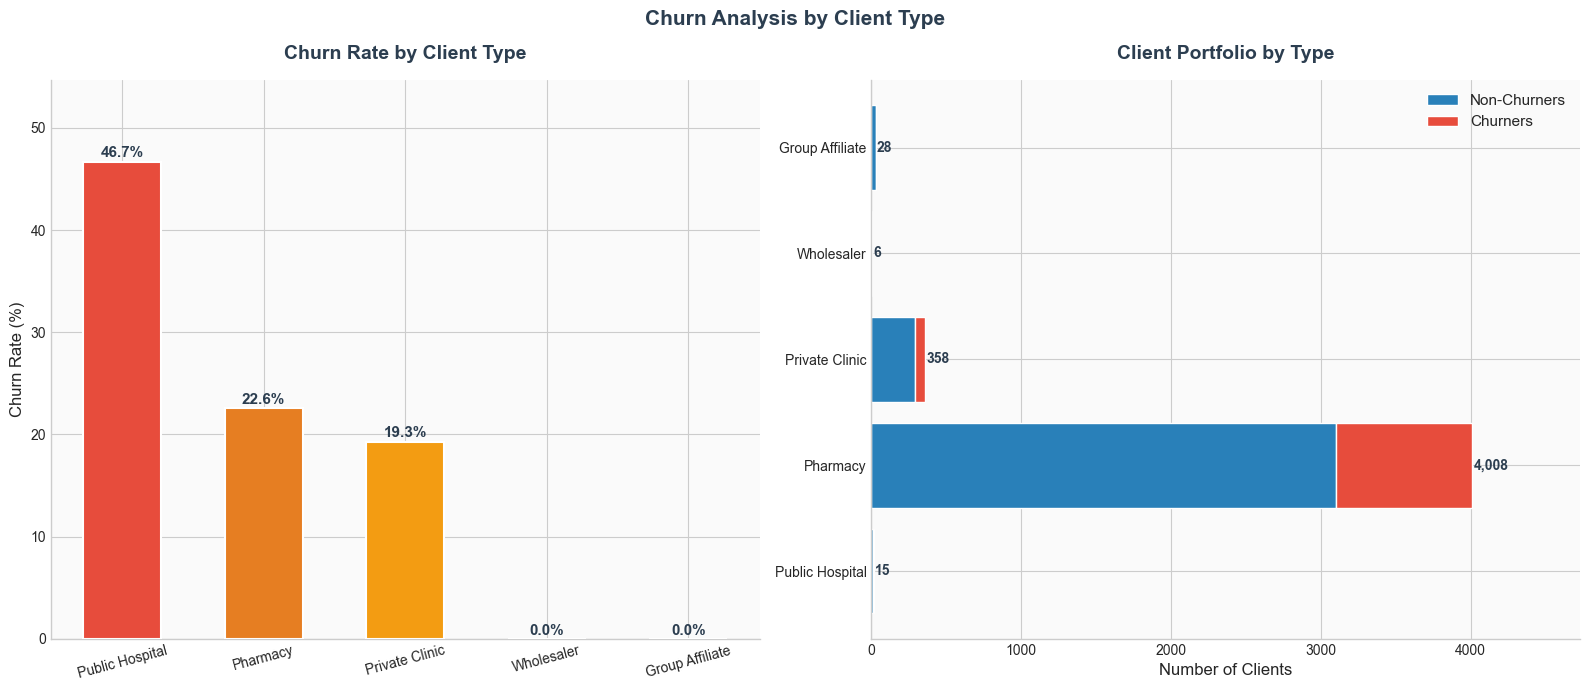

✅ churn_by_client_type.png saved


In [47]:
churn_by_act = df.groupby('ACTIVITE')['Churn'].agg(
    Churners='sum', Total='count', Churn_Rate='mean'
).reset_index()
churn_by_act['Churn_Rate'] = (churn_by_act['Churn_Rate'] * 100).round(1)
churn_by_act = churn_by_act.sort_values('Churn_Rate', ascending=False)

act_labels = {
    'OFFICINE PHARMACEUTIQUE': 'Pharmacy',
    'ETS DE SANTE PRIVE':      'Private Clinic',
    'ETS DISTRIBUTION EN GROS':'Wholesaler',
    'ETS DE SANTE PUBLIQUE':   'Public Hospital',
    'FILIALE DU GROUPE':       'Group Affiliate'
}
churn_by_act['ACTIVITE_EN'] = churn_by_act['ACTIVITE'].map(act_labels).fillna(churn_by_act['ACTIVITE'])

palette = [COLORS['churn'], '#E67E22', '#F39C12', COLORS['accent'], COLORS['no_churn']]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('white')

bars = axes[0].bar(churn_by_act['ACTIVITE_EN'], churn_by_act['Churn_Rate'],
                    color=palette[:len(churn_by_act)], edgecolor='white',
                    linewidth=1.5, width=0.55, zorder=3)
axes[0].set_title('Churn Rate by Client Type', fontsize=14, fontweight='bold',
                   color=COLORS['primary'], pad=15)
axes[0].set_ylabel('Churn Rate (%)', fontsize=12)
axes[0].set_facecolor('#FAFAFA')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_ylim(0, churn_by_act['Churn_Rate'].max() + 8)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, churn_by_act['Churn_Rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{val}%', ha='center', fontsize=11, fontweight='bold',
                color=COLORS['primary'])

non_ch = churn_by_act['Total'] - churn_by_act['Churners']
axes[1].barh(churn_by_act['ACTIVITE_EN'], non_ch,
             color=COLORS['no_churn'], edgecolor='white', label='Non-Churners')
axes[1].barh(churn_by_act['ACTIVITE_EN'], churn_by_act['Churners'],
             left=non_ch, color=COLORS['churn'], edgecolor='white', label='Churners')
axes[1].set_title('Client Portfolio by Type', fontsize=14, fontweight='bold',
                   color=COLORS['primary'], pad=15)
axes[1].set_xlabel('Number of Clients', fontsize=12)
axes[1].set_facecolor('#FAFAFA')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].legend(fontsize=11)

# ✅ Total clients at end of each bar
for i, total in enumerate(churn_by_act['Total']):
    axes[1].text(total + 10, i, f'{total:,}',
                 va='center', fontsize=10,
                 fontweight='bold', color=COLORS['primary'])

axes[1].set_xlim(0, churn_by_act['Total'].max() * 1.18)

plt.suptitle('Churn Analysis by Client Type',
             fontsize=15, fontweight='bold', color=COLORS['primary'])
plt.tight_layout()
plt.savefig('churn_by_client_type.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ churn_by_client_type.png saved")

### Churn by Convention Status

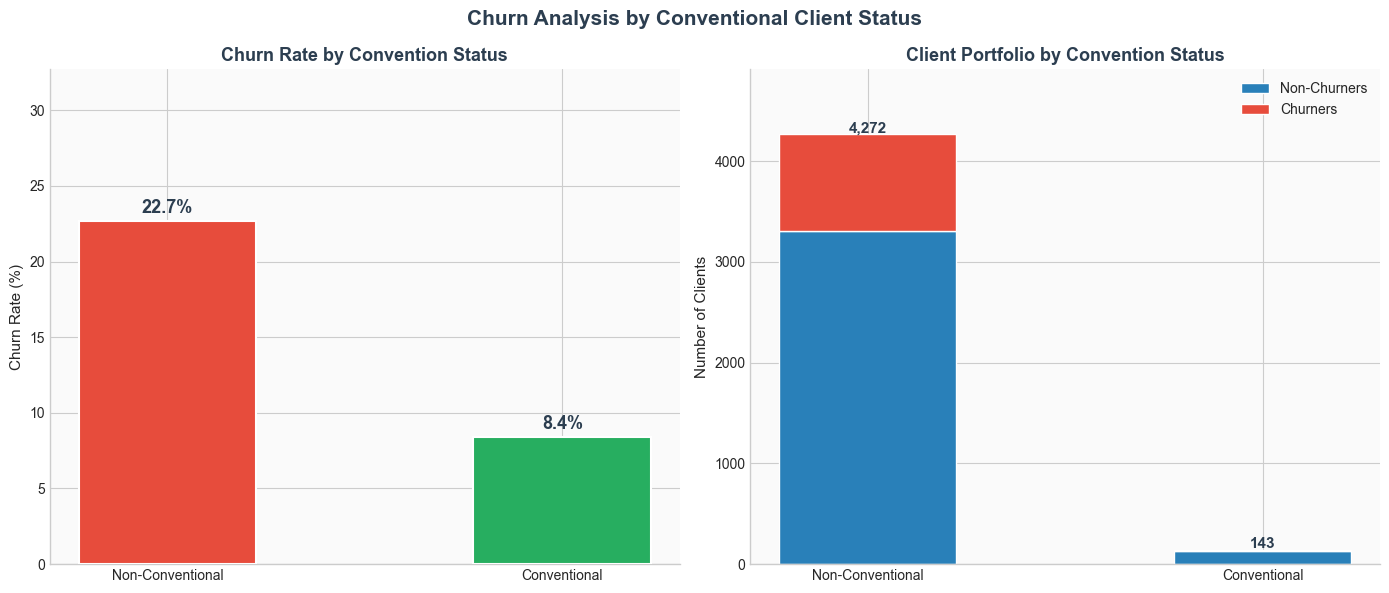

✅ churn_by_conventional.png saved


In [42]:
churn_by_conv = df.groupby('STAUT_CONVENTION')['Churn'].agg(
    Churners='sum', Total='count', Churn_Rate='mean'
).reset_index()
churn_by_conv['Churn_Rate'] = (churn_by_conv['Churn_Rate'] * 100).round(1)
churn_by_conv['Status'] = churn_by_conv['STAUT_CONVENTION'].map({0: 'Non-Conventional', 1: 'Conventional'})
churn_by_conv['Non_Churners'] = churn_by_conv['Total'] - churn_by_conv['Churners']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')

colors_conv = [COLORS['churn'], COLORS['accent']]
bars = axes[0].bar(churn_by_conv['Status'], churn_by_conv['Churn_Rate'],
                    color=colors_conv, edgecolor='white', linewidth=1.5, width=0.45, zorder=3)
axes[0].set_title('Churn Rate by Convention Status', fontsize=13, fontweight='bold',
                   color=COLORS['primary'])
axes[0].set_ylabel('Churn Rate (%)', fontsize=11)
axes[0].set_facecolor('#FAFAFA')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
axes[0].set_ylim(0, churn_by_conv['Churn_Rate'].max() + 10)
for bar, val in zip(bars, churn_by_conv['Churn_Rate']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{val}%', ha='center', fontsize=13, fontweight='bold',
                color=COLORS['primary'])

axes[1].bar(churn_by_conv['Status'], churn_by_conv['Non_Churners'],
            color=COLORS['no_churn'], label='Non-Churners', edgecolor='white', width=0.45)
axes[1].bar(churn_by_conv['Status'], churn_by_conv['Churners'],
            bottom=churn_by_conv['Non_Churners'], color=COLORS['churn'],
            label='Churners', edgecolor='white', width=0.45)
axes[1].set_title('Client Portfolio by Convention Status', fontsize=13,
                   fontweight='bold', color=COLORS['primary'])
axes[1].set_ylabel('Number of Clients', fontsize=11)
axes[1].set_facecolor('#FAFAFA')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
axes[1].legend(fontsize=10)

# ✅ Total clients on top of each bar
for i, total in enumerate(churn_by_conv['Total']):
    axes[1].text(i, total + 15, f'{total:,}',
                 ha='center', fontsize=11,
                 fontweight='bold', color=COLORS['primary'])

axes[1].set_ylim(0, churn_by_conv['Total'].max() * 1.15)

plt.suptitle('Churn Analysis by Conventional Client Status',
             fontsize=15, fontweight='bold', color=COLORS['primary'])
plt.tight_layout()
plt.savefig('churn_by_conventional.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ churn_by_conventional.png saved")

### Churn Rate by Payment Method

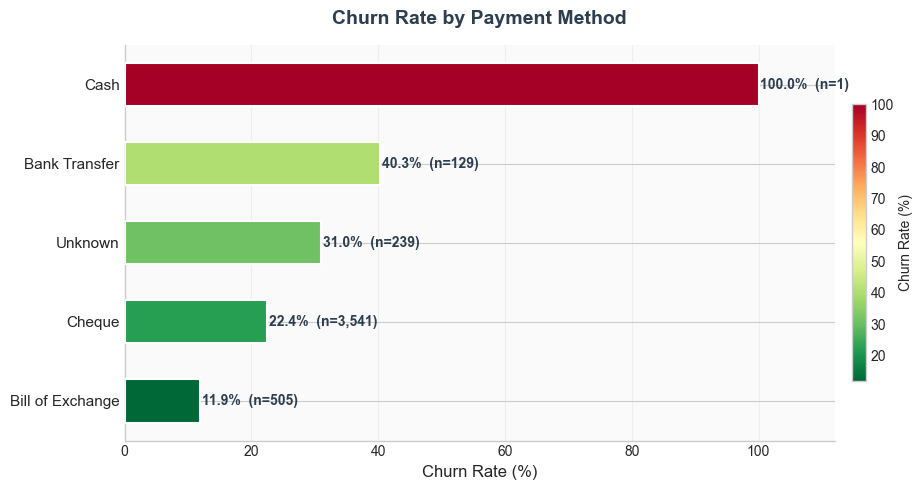

✅ churn_by_payment_method.png saved


In [ ]:
payment_map = {
    'Chèque'   : 'Cheque',
    'Traite'   : 'Bill of Exchange',
    'Virement' : 'Bank Transfer',
    'Espèce'   : 'Cash',
    'Unknown'  : 'Unknown',
}
df['Payment_Method_EN'] = df['Payment_Method'].map(payment_map).fillna(df['Payment_Method'])
churn_pm = (df.groupby('Payment_Method_EN')['Churn']
            .agg(Churners='sum', Total='count', Churn_Rate='mean')
            .reset_index())
churn_pm['Churn_Rate']   = (churn_pm['Churn_Rate'] * 100).round(1)
churn_pm['Non_Churners'] = churn_pm['Total'] - churn_pm['Churners']
churn_pm = churn_pm.sort_values('Churn_Rate', ascending=True)

# ✅ Single centered figure
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('white')

norm   = plt.Normalize(churn_pm['Churn_Rate'].min(), churn_pm['Churn_Rate'].max())
colors = [plt.cm.RdYlGn_r(norm(v)) for v in churn_pm['Churn_Rate']]

bars = ax.barh(churn_pm['Payment_Method_EN'], churn_pm['Churn_Rate'],
               color=colors, edgecolor='white', linewidth=1.5,
               height=0.55, zorder=3)

for bar, val, tot in zip(bars, churn_pm['Churn_Rate'], churn_pm['Total']):
    ax.text(val + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val}%  (n={tot:,})', va='center', fontsize=10,
            fontweight='bold', color=COLORS['primary'])

ax.set_title('Churn Rate by Payment Method',
             fontsize=14, fontweight='bold', color=COLORS['primary'], pad=15)
ax.set_xlabel('Churn Rate (%)', fontsize=12)
ax.set_xlim(0, churn_pm['Churn_Rate'].max() + 12)
ax.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='x', alpha=0.4, color='#DDDDDD')
ax.tick_params(axis='y', labelsize=11)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02, label='Churn Rate (%)')

plt.tight_layout()
plt.savefig('churn_by_payment_method.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ churn_by_payment_method.png saved")

### Average number of account blockage incidents by churn status 

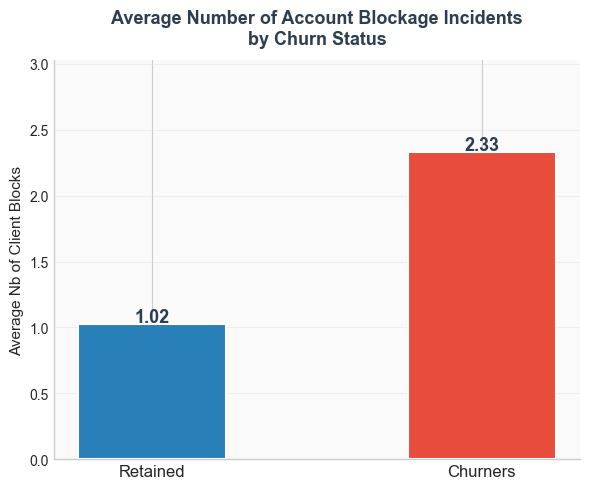

✅ client_blocks_analysis.png saved


In [15]:
block_stats = df.groupby('Churn')['Nb_Blockages'].agg(
    Mean='mean'
).reset_index()
block_stats['Churn_Label'] = block_stats['Churn'].map({0: 'Retained', 1: 'Churners'})

fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('white')

bars = ax.bar(
    block_stats['Churn_Label'],
    block_stats['Mean'],
    color=[COLORS['no_churn'], COLORS['churn']],
    edgecolor='white', linewidth=1.5,
    width=0.45, zorder=3
)
for bar, val in zip(bars, block_stats['Mean']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{val:.2f}', ha='center', fontsize=13,
            fontweight='bold', color=COLORS['primary'])

ax.set_title('Average Number of Account Blockage Incidents\nby Churn Status',
             fontsize=13, fontweight='bold',
             color=COLORS['primary'], pad=12)
ax.set_ylabel('Average Nb of Client Blocks', fontsize=11)
ax.set_ylim(0, block_stats['Mean'].max() * 1.3)
ax.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.4, color='#DDDDDD')
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.savefig('client_blocks_analysis.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ client_blocks_analysis.png saved")

### Average Revenue per Client Status

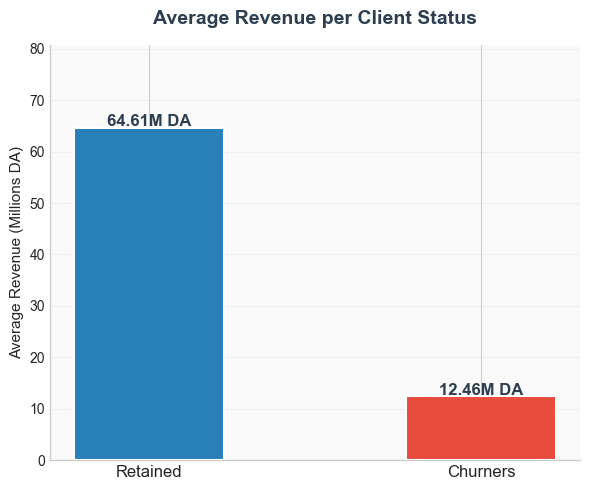

✅ revenue_churners_vs_retained.png saved


In [53]:
avg_rev_retained = df[df['Churn']==0]['Total_Revenue_DA'].mean()
avg_rev_churner  = df[df['Churn']==1]['Total_Revenue_DA'].mean()

# ✅ Single centered figure
fig, ax = plt.subplots(figsize=(6, 5))
fig.patch.set_facecolor('white')

labels = ['Retained', 'Churners']
values = [avg_rev_retained / 1e6, avg_rev_churner / 1e6]
colors = [COLORS['no_churn'], COLORS['churn']]

bars = ax.bar(labels, values, color=colors, edgecolor='white',
              linewidth=1.5, width=0.45, zorder=3)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.2f}M DA', ha='center', fontsize=12,
            fontweight='bold', color=COLORS['primary'])

ax.set_title('Average Revenue per Client Status', fontsize=14, fontweight='bold',
             color=COLORS['primary'], pad=15)
ax.set_ylabel('Average Revenue (Millions DA)', fontsize=11)
ax.set_ylim(0, max(values) * 1.25)
ax.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.4, color='#DDDDDD')
ax.tick_params(axis='x', labelsize=12)

plt.tight_layout()
plt.savefig('revenue_churners_vs_retained.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ revenue_churners_vs_retained.png saved")

### RFM Score Analysis

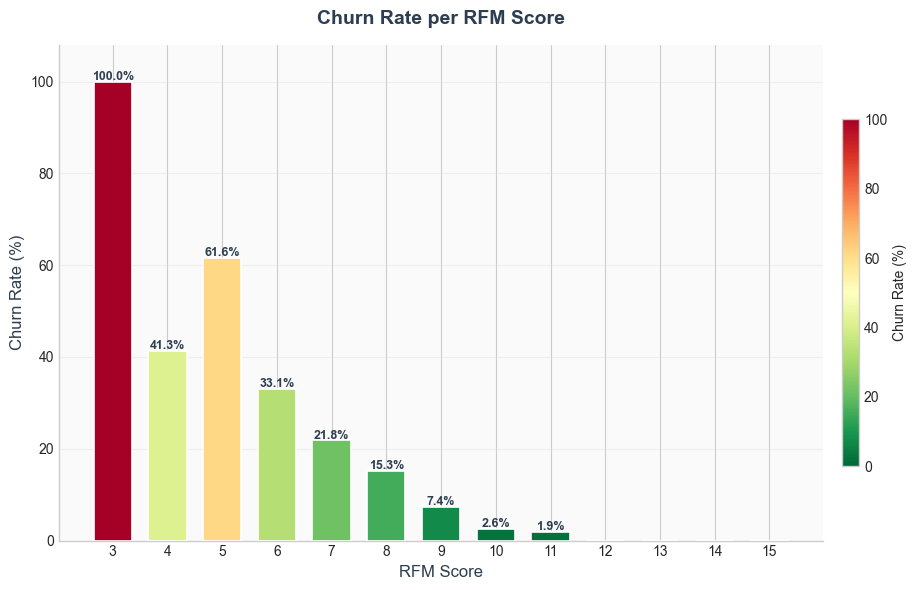

✅ rfm_churn_rate.png saved


In [43]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('white')

x = np.arange(3, 16)

rfm_churn_rate = df.groupby('RFM_Score')['Churn'].mean() * 100
rfm_churn_rate = rfm_churn_rate.reindex(x, fill_value=0)

norm   = plt.Normalize(rfm_churn_rate.min(), rfm_churn_rate.max())
colors = [plt.cm.RdYlGn_r(norm(v)) for v in rfm_churn_rate.values]

bars = ax.bar(rfm_churn_rate.index, rfm_churn_rate.values,
              color=colors, edgecolor='white', linewidth=1.2,
              width=0.7, zorder=3)

for bar, val in zip(bars, rfm_churn_rate.values):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                f'{val:.1f}%', ha='center', fontsize=9,
                fontweight='bold', color=COLORS['primary'])

ax.set_title('Churn Rate per RFM Score',
             fontsize=14, fontweight='bold', color=COLORS['primary'], pad=15)
ax.set_xlabel('RFM Score', fontsize=12, color=COLORS['primary'])
ax.set_ylabel('Churn Rate (%)', fontsize=12, color=COLORS['primary'])
ax.set_xticks(x)
ax.set_xticklabels(x, fontsize=10)
ax.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.4, color='#DDDDDD')
ax.set_ylim(0, rfm_churn_rate.max() + 8)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn_r, norm=norm)
sm.set_array([])
plt.colorbar(sm, ax=ax, shrink=0.7, pad=0.02, label='Churn Rate (%)')

plt.tight_layout()
plt.savefig('rfm_churn_rate.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ rfm_churn_rate.png saved")

### Boxplots

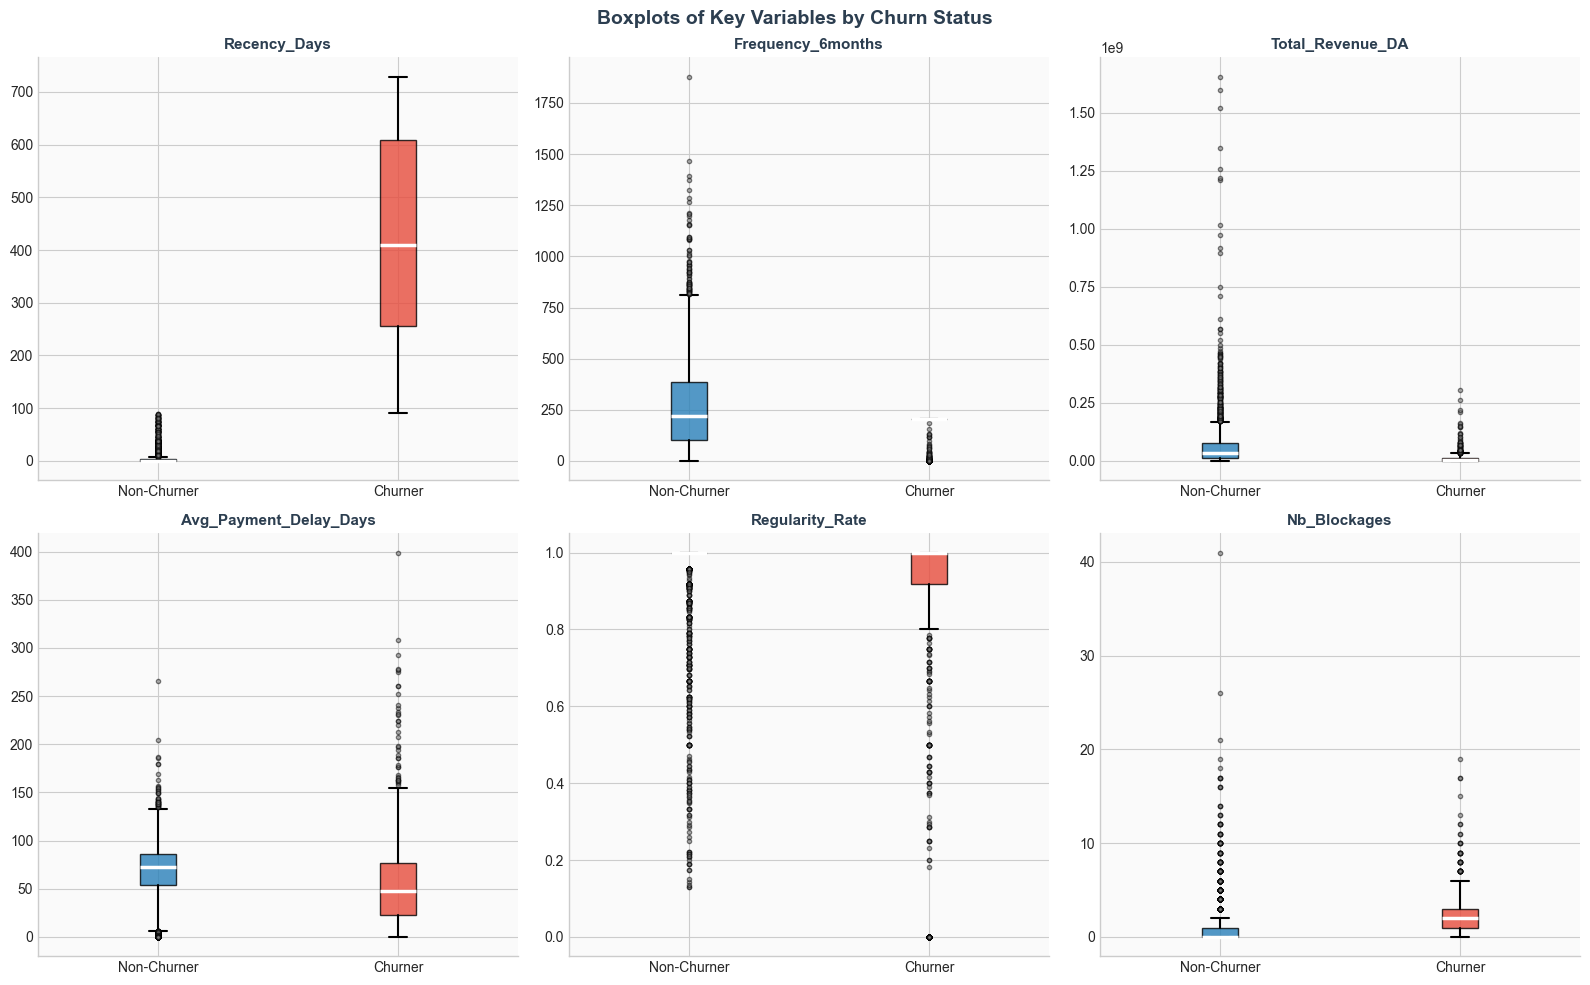

✅ boxplots_by_churn.png saved


In [40]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.patch.set_facecolor('white')
axes = axes.flatten()

for i, var in enumerate(plot_vars):
    bp = axes[i].boxplot(
        [df[df['Churn']==0][var].dropna(), df[df['Churn']==1][var].dropna()],
        labels=['Non-Churner','Churner'], patch_artist=True,
        medianprops=dict(color='white', linewidth=2.5),
        whiskerprops=dict(linewidth=1.5), capprops=dict(linewidth=1.5),
        flierprops=dict(marker='o', markerfacecolor='gray', markersize=3, alpha=0.5)
    )
    bp['boxes'][0].set_facecolor(COLORS['no_churn'])
    bp['boxes'][0].set_alpha(0.8)
    bp['boxes'][1].set_facecolor(COLORS['churn'])
    bp['boxes'][1].set_alpha(0.8)
    axes[i].set_title(var, fontweight='bold', fontsize=11, color=COLORS['primary'])
    axes[i].set_facecolor('#FAFAFA')
    axes[i].spines['top'].set_visible(False)
    axes[i].spines['right'].set_visible(False)

plt.suptitle('Boxplots of Key Variables by Churn Status',
             fontsize=14, fontweight='bold', color=COLORS['primary'])
plt.tight_layout()
plt.savefig('boxplots_by_churn.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ boxplots_by_churn.png saved")

### Correlation Matrix

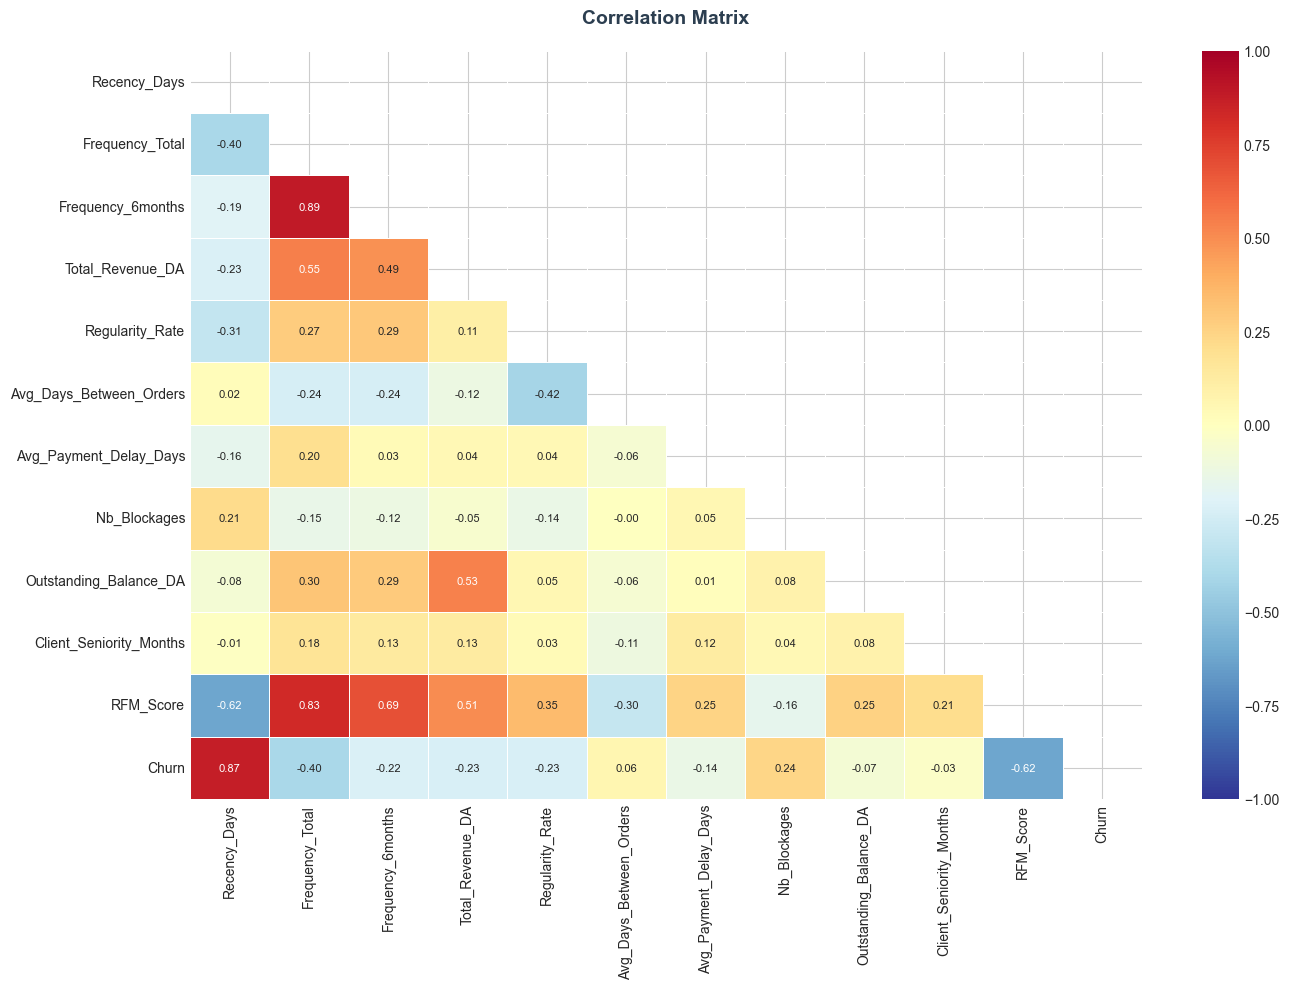


Top correlations with Churn :
Recency_Days               0.875
RFM_Score                 -0.623
Frequency_Total           -0.403
Nb_Blockages               0.240
Total_Revenue_DA          -0.231
Regularity_Rate           -0.231
Frequency_6months         -0.220
Avg_Payment_Delay_Days    -0.140
Outstanding_Balance_DA    -0.072
Avg_Days_Between_Orders    0.062
Client_Seniority_Months   -0.030
Name: Churn, dtype: float64
✅ correlation_matrix.png saved


In [ ]:
num_cols_corr = ['Recency_Days','Frequency_Total','Frequency_6months',
                  'Total_Revenue_DA','Regularity_Rate','Avg_Days_Between_Orders',
                  'Avg_Payment_Delay_Days','Nb_Blockages','Outstanding_Balance_DA',
                  'Client_Seniority_Months','RFM_Score','Churn']

corr_matrix = df[num_cols_corr].corr()

fig, ax = plt.subplots(figsize=(14, 10))
fig.patch.set_facecolor('white')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor='white', annot_kws={'size': 8}, ax=ax)
ax.set_title('Correlation Matrix',
             fontsize=14, fontweight='bold', color=COLORS['primary'], pad=20)
plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

print("\nTop correlations with Churn :")
print(corr_matrix['Churn'].drop('Churn').sort_values(key=abs, ascending=False).round(3))
print("✅ correlation_matrix.png saved")

## STEP 9 — ENCODING & FEATURE SELECTION

In [16]:
df_model = df.copy()

# Binary encoding
df_model['Conventional_Client_Enc'] = df_model['STAUT_CONVENTION'].astype(int)
df_model['Pre_Litigation_Enc']      = df_model['Pre_Litigation'].astype(int)

# One-Hot Encoding for ACTIVITE and Payment_Method
df_model = pd.get_dummies(df_model, columns=['ACTIVITE', 'Payment_Method'], drop_first=False)

# Columns to drop
cols_to_drop = [
    'CODE_CLIENT', 'ENTITE', 'REGION', 'SEGMENT',
    'DATE_INTEGRATION_CLIENT', 'Last_Order_Date',
    'STAUT_CONVENTION', 'Pre_Litigation',
    'Revenue_Period_N_DA', 'Revenue_Period_N1_DA',
    'Total_Avoir_DA', 'Avg_Revenue_per_Transaction',
    'Total_Quantity', 'Total_Paid', 'Nb_Payments_Total',
    'Active_Months', 'Portfolio_Duration_Months',
    'R_Score', 'F_Score', 'M_Score',
    'CODE_WILAYA', 'DELAIS_PAIEMENT', 'LIMITE_CREDIT',
    'NUM_TRANSACTION', 'Frequency_6months', 'Recency_Days',
]

# Drop only if column exists
cols_to_drop = [c for c in cols_to_drop if c in df_model.columns]
df_model = df_model.drop(columns=cols_to_drop)

# Drop target
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# Keep only numeric
X = X.select_dtypes(include=[np.number])

print(f"Final dataset shape : {df_model.shape}")
print(f"Features            : {X.shape[1]}")
print(f"Churn rate          : {y.mean()*100:.1f}%")
print(f"\nFeature list :")
for i, col in enumerate(X.columns):
    print(f"  {i+1:02d}. {col}")

Final dataset shape : (4415, 28)
Features            : 17
Churn rate          : 22.2%

Feature list :
  01. Frequency_Total
  02. Total_Revenue_DA
  03. Regularity_Rate
  04. Avg_Days_Between_Orders
  05. Nb_Distinct_Products
  06. Avg_Order_Lines
  07. Nb_Cancelled_Returned_Orders
  08. Nb_Blockages
  09. Nb_Late_Payments
  10. Avg_Payment_Delay_Days
  11. Outstanding_Balance_DA
  12. Client_Seniority_Months
  13. Revenue_Evolution_Pct
  14. RFM_Score
  15. Discount_Rate
  16. Conventional_Client_Enc
  17. Pre_Litigation_Enc


## STEP 10 — STANDARDIZATION + TRAIN/TEST SPLIT

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Identify binary columns
binary_cols = [c for c in X.columns if X[c].nunique() == 2]
num_cols_sc  = [c for c in X.columns if c not in binary_cols]

scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[num_cols_sc] = scaler.fit_transform(X[num_cols_sc])

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Numerical columns scaled : {len(num_cols_sc)}")
print(f"Binary columns kept      : {len(binary_cols)}")
print(f"Training set : {X_train.shape[0]} samples (80%)")
print(f"Test set     : {X_test.shape[0]} samples (20%)")
print(f"Train churn rate : {y_train.mean()*100:.1f}%")
print(f"Test  churn rate : {y_test.mean()*100:.1f}%")

Numerical columns scaled : 15
Binary columns kept      : 2
Training set : 3532 samples (80%)
Test set     : 883 samples (20%)
Train churn rate : 22.2%
Test  churn rate : 22.2%


## STEP 11 — DATA LEAKAGE VERIFICATION
### Threshold : single-feature AUC > 0.95 => potential leakage

In [18]:
from sklearn.linear_model import LogisticRegression as LR_check
from sklearn.metrics import roc_auc_score

single_aucs = {}
for col in X_train.columns:
    try:
        m = LR_check(random_state=42, max_iter=200)
        m.fit(X_train[[col]], y_train)
        auc = roc_auc_score(y_test, m.predict_proba(X_test[[col]])[:,1])
        single_aucs[col] = round(auc, 4)
    except:
        single_aucs[col] = 0.0

single_auc_series = pd.Series(single_aucs).sort_values(ascending=False)
print("\nTop 10 individual feature AUCs :")
print(single_auc_series.head(10).to_string())

suspects = single_auc_series[single_auc_series > 0.95]
if len(suspects) > 0:
    print(f"\n⚠️  Potential leakage : {list(suspects.index)}")
    print("Consider dropping these variables before modeling.")
else:
    print(f"\n✅ No leakage detected — max single-feature AUC : {single_auc_series.max():.4f}")


Top 10 individual feature AUCs :
RFM_Score                       0.9355
Frequency_Total                 0.8438
Nb_Distinct_Products            0.8438
Total_Revenue_DA                0.8410
Nb_Cancelled_Returned_Orders    0.7924
Nb_Blockages                    0.7790
Revenue_Evolution_Pct           0.7664
Avg_Payment_Delay_Days          0.6444
Avg_Days_Between_Orders         0.6135
Regularity_Rate                 0.6025

✅ No leakage detected — max single-feature AUC : 0.9355


## STEP 12 — SMOTE (train set only)

Before SMOTE :
  Non-churners : 2,747
  Churners     : 785
  Churn rate   : 22.2%

After SMOTE :
  Non-churners : 2,747
  Churners     : 2,747
  Churn rate   : 50.0%

Test set unchanged :
  Non-churners : 687
  Churners     : 196


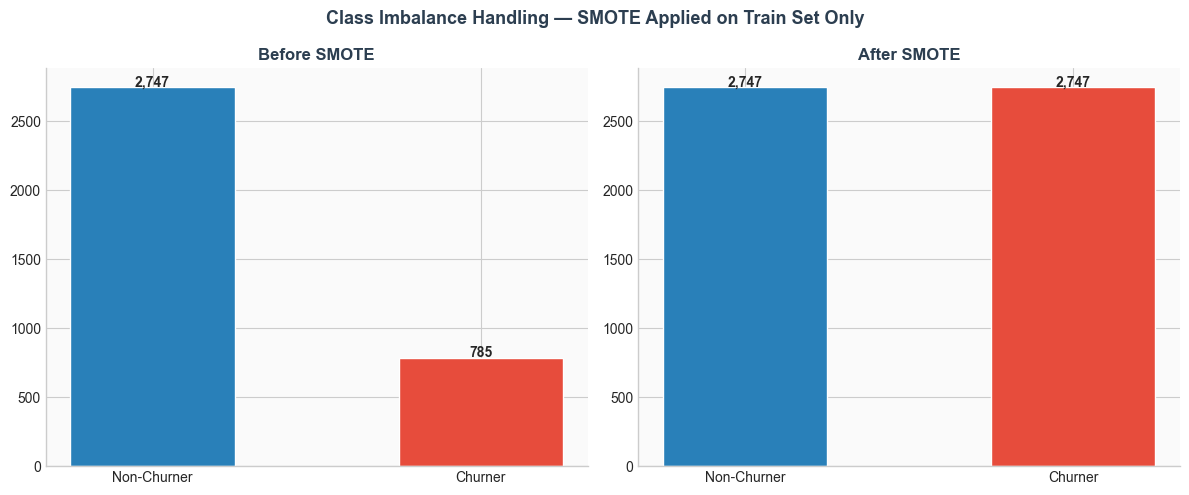

✅ smote.png saved


In [19]:
from imblearn.over_sampling import SMOTE

print(f"Before SMOTE :")
print(f"  Non-churners : {(y_train==0).sum():,}")
print(f"  Churners     : {(y_train==1).sum():,}")
print(f"  Churn rate   : {y_train.mean()*100:.1f}%")

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"\nAfter SMOTE :")
print(f"  Non-churners : {(y_train_resampled==0).sum():,}")
print(f"  Churners     : {(y_train_resampled==1).sum():,}")
print(f"  Churn rate   : {y_train_resampled.mean()*100:.1f}%")
print(f"\nTest set unchanged :")
print(f"  Non-churners : {(y_test==0).sum():,}")
print(f"  Churners     : {(y_test==1).sum():,}")

# SMOTE visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.patch.set_facecolor('white')

for ax, counts, title in zip(
    axes,
    [(y_train==0).sum(), (y_train==1).sum()],
    ['Before SMOTE', 'After SMOTE']
):
    pass

axes[0].bar(['Non-Churner','Churner'],
            [(y_train==0).sum(), (y_train==1).sum()],
            color=[COLORS['no_churn'], COLORS['churn']], edgecolor='white', width=0.5)
axes[0].set_title('Before SMOTE', fontweight='bold', fontsize=12, color=COLORS['primary'])
axes[0].set_facecolor('#FAFAFA')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)
for i, v in enumerate([(y_train==0).sum(), (y_train==1).sum()]):
    axes[0].text(i, v + 5, f'{v:,}', ha='center', fontweight='bold')

axes[1].bar(['Non-Churner','Churner'],
            [(y_train_resampled==0).sum(), (y_train_resampled==1).sum()],
            color=[COLORS['no_churn'], COLORS['churn']], edgecolor='white', width=0.5)
axes[1].set_title('After SMOTE', fontweight='bold', fontsize=12, color=COLORS['primary'])
axes[1].set_facecolor('#FAFAFA')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)
for i, v in enumerate([(y_train_resampled==0).sum(), (y_train_resampled==1).sum()]):
    axes[1].text(i, v + 5, f'{v:,}', ha='center', fontweight='bold')

plt.suptitle('Class Imbalance Handling — SMOTE Applied on Train Set Only',
             fontsize=13, fontweight='bold', color=COLORS['primary'])
plt.tight_layout()
plt.savefig('smote.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ smote.png saved")

## STEP 13 — IMPORTS AND SETUP

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix, roc_curve)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ALL_RESULTS = []

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:,1]
    y_prob_tr = model.predict_proba(X_tr)[:,1]
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred, zero_division=0)
    rec  = recall_score(y_te, y_pred, zero_division=0)
    f1   = f1_score(y_te, y_pred, zero_division=0)
    auc  = roc_auc_score(y_te, y_prob)
    tr_auc = roc_auc_score(y_tr, y_prob_tr)
    gap  = tr_auc - auc
    status = "✅ No overfitting" if gap < 0.05 else "⚠️ Possible overfitting"
    print(f"\nTest Set Results :")
    print(f"Accuracy  : {acc:.4f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1-Score  : {f1:.4f}")
    print(f"AUC-ROC   : {auc:.4f}")
    print(f"\nOverfitting Check :")
    print(f"  Train AUC : {tr_auc:.4f}")
    print(f"  Test  AUC : {auc:.4f}")
    print(f"  Gap       : {gap:.4f} {status}")
    ALL_RESULTS.append({
        'Model': name, 'Accuracy': round(acc,4),
        'Precision': round(prec,4), 'Recall': round(rec,4),
        'F1': round(f1,4), 'AUC_ROC': round(auc,4),
        'Train_AUC': round(tr_auc,4), 'Gap': round(gap,4)
    })
    return y_pred, y_prob

def plot_cm(cm, model_name, accuracy, ax):
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax, shrink=0.8)
    ax.set(xticks=[0,1], yticks=[0,1],
           xticklabels=['No Churn','Churn'],
           yticklabels=['No Churn','Churn'],
           ylabel='Actual', xlabel='Predicted',
           title=f'{model_name}\nAccuracy: {accuracy:.3f}')
    ax.title.set_fontsize(11)
    ax.title.set_fontweight('bold')
    ax.title.set_color(COLORS['primary'])
    ax.set_xticks([], minor=True)
    ax.set_yticks([], minor=True)
    ax.grid(False)
    thresh = cm.max() / 2.0
    for i in range(2):
        for j in range(2):
            ax.text(j, i, format(cm[i,j],'d'), ha='center', va='center',
                    fontsize=13, fontweight='bold',
                    color='white' if cm[i,j] > thresh else COLORS['primary'])
    ax.set_facecolor('white')

print("✅ Model setup ready")

✅ Model setup ready


## MODEL 1 — LOGISTIC REGRESSION

Best parameters : {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV AUC-ROC : 0.9710

Test Set Results :
Accuracy  : 0.9015
Precision : 0.7121
Recall    : 0.9337
F1-Score  : 0.8079
AUC-ROC   : 0.9791

Overfitting Check :
  Train AUC : 0.9725
  Test  AUC : 0.9791
  Gap       : -0.0067 ✅ No overfitting


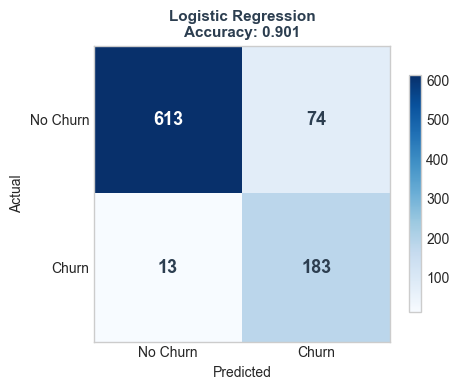

In [21]:
param_grid_lr = {'C': [0.001,0.01,0.1,1,10,100], 'penalty': ['l1','l2'], 'solver': ['liblinear']}
grid_lr = GridSearchCV(LogisticRegression(random_state=42, max_iter=1000),
                       param_grid_lr, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_lr.fit(X_train_resampled, y_train_resampled)

print(f"Best parameters : {grid_lr.best_params_}")
print(f"Best CV AUC-ROC : {grid_lr.best_score_:.4f}")
lr = grid_lr.best_estimator_
y_pred_lr, y_prob_lr = evaluate_model('Logistic Regression', lr,
                                       X_train_resampled, y_train_resampled, X_test, y_test)
fig, ax = plt.subplots(figsize=(5,4)); fig.patch.set_facecolor('white')
plot_cm(confusion_matrix(y_test, y_pred_lr), 'Logistic Regression',
        accuracy_score(y_test, y_pred_lr), ax)
plt.tight_layout()
plt.savefig('cm_logistic_regression.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## MODEL 2 — DECISION TREE

Best parameters : {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 30}
Best CV AUC-ROC : 0.9840

Test Set Results :
Accuracy  : 0.9411
Precision : 0.8051
Recall    : 0.9694
F1-Score  : 0.8796
AUC-ROC   : 0.9843

Overfitting Check :
  Train AUC : 0.9911
  Test  AUC : 0.9843
  Gap       : 0.0068 ✅ No overfitting


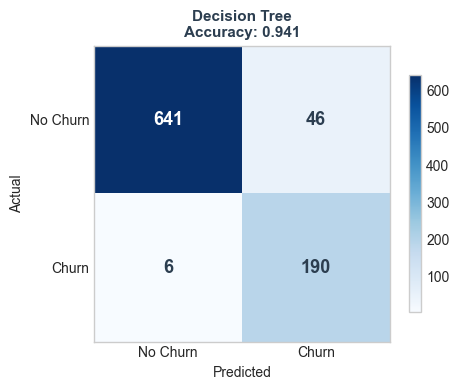

In [22]:
param_grid_dt = {'max_depth': [3,4,5], 'min_samples_split': [10,20,30],
                  'min_samples_leaf': [4,8,12], 'criterion': ['gini','entropy']}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42, class_weight='balanced'),
                       param_grid_dt, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_dt.fit(X_train_resampled, y_train_resampled)

print(f"Best parameters : {grid_dt.best_params_}")
print(f"Best CV AUC-ROC : {grid_dt.best_score_:.4f}")
dt = grid_dt.best_estimator_
y_pred_dt, y_prob_dt = evaluate_model('Decision Tree', dt,
                                       X_train_resampled, y_train_resampled, X_test, y_test)
fig, ax = plt.subplots(figsize=(5,4)); fig.patch.set_facecolor('white')
plot_cm(confusion_matrix(y_test, y_pred_dt), 'Decision Tree',
        accuracy_score(y_test, y_pred_dt), ax)
plt.tight_layout()
plt.savefig('cm_decision_tree.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## MODEL 3 — RANDOM FOREST

Best parameters : {'class_weight': 'balanced', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV AUC-ROC : 0.9983

Test Set Results :
Accuracy  : 0.9785
Precision : 0.9447
Recall    : 0.9592
F1-Score  : 0.9519
AUC-ROC   : 0.9974

Overfitting Check :
  Train AUC : 1.0000
  Test  AUC : 0.9974
  Gap       : 0.0026 ✅ No overfitting


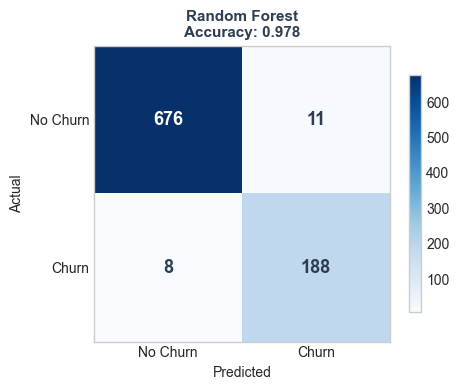

In [23]:
param_grid_rf = {'n_estimators': [100,200,300], 'max_depth': [5,10,15,None],
                  'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4],
                  'max_features': ['sqrt','log2'], 'class_weight': ['balanced']}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42, n_jobs=-1),
                       param_grid_rf, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train_resampled, y_train_resampled)

print(f"Best parameters : {grid_rf.best_params_}")
print(f"Best CV AUC-ROC : {grid_rf.best_score_:.4f}")
rf = grid_rf.best_estimator_
y_pred_rf, y_prob_rf = evaluate_model('Random Forest', rf,
                                       X_train_resampled, y_train_resampled, X_test, y_test)
fig, ax = plt.subplots(figsize=(5,4)); fig.patch.set_facecolor('white')
plot_cm(confusion_matrix(y_test, y_pred_rf), 'Random Forest',
        accuracy_score(y_test, y_pred_rf), ax)
plt.tight_layout()
plt.savefig('cm_random_forest.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## MODEL 4 — GRADIENT BOOSTING

Best parameters : {'subsample': 0.8, 'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 5, 'learning_rate': 0.1}
Best CV AUC-ROC : 0.9988

Test Set Results :
Accuracy  : 0.9796
Precision : 0.9450
Recall    : 0.9643
F1-Score  : 0.9545
AUC-ROC   : 0.9965

Overfitting Check :
  Train AUC : 1.0000
  Test  AUC : 0.9965
  Gap       : 0.0035 ✅ No overfitting


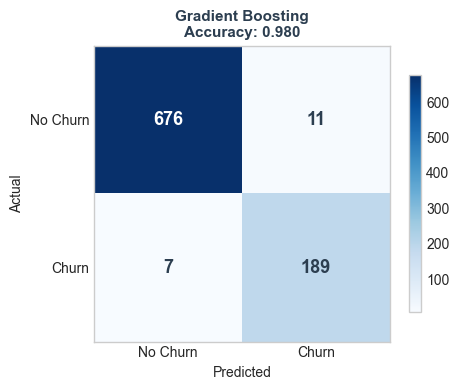

In [24]:
param_grid_gb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
random_gb = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid_gb, cv=cv, scoring='roc_auc', n_iter=40,
    random_state=42, n_jobs=-1)
random_gb.fit(X_train_resampled, y_train_resampled)

print(f"Best parameters : {random_gb.best_params_}")
print(f"Best CV AUC-ROC : {random_gb.best_score_:.4f}")
gb = random_gb.best_estimator_
y_pred_gb, y_prob_gb = evaluate_model('Gradient Boosting', gb,
                                       X_train_resampled, y_train_resampled, X_test, y_test)
fig, ax = plt.subplots(figsize=(5,4)); fig.patch.set_facecolor('white')
plot_cm(confusion_matrix(y_test, y_pred_gb), 'Gradient Boosting',
        accuracy_score(y_test, y_pred_gb), ax)
plt.tight_layout()
plt.savefig('cm_gradient_boosting.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## MODEL 5 — XGBOOST

Best parameters : {'subsample': 0.8, 'reg_lambda': 1.5, 'reg_alpha': 0.01, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.8}
Best CV AUC-ROC : 0.9986

Test Set Results :
Accuracy  : 0.9796
Precision : 0.9541
Recall    : 0.9541
F1-Score  : 0.9541
AUC-ROC   : 0.9968

Overfitting Check :
  Train AUC : 0.9999
  Test  AUC : 0.9968
  Gap       : 0.0031 ✅ No overfitting


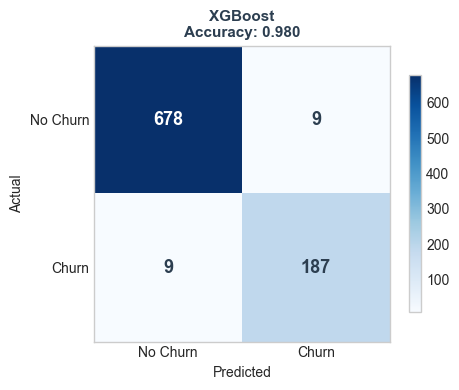

In [25]:
param_grid_xgb = {
    'n_estimators': [200,300,500], 'max_depth': [3,4,5],
    'learning_rate': [0.01,0.05], 'subsample': [0.7,0.8],
    'colsample_bytree': [0.7,0.8], 'min_child_weight': [3,5,7],
    'gamma': [0.1,0.2,0.3], 'reg_alpha': [0.01,0.1,0.5], 'reg_lambda': [1.5,2,3]
}
random_xgb = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='auc', use_label_encoder=False),
    param_grid_xgb, cv=cv, scoring='roc_auc', n_iter=60,
    random_state=42, n_jobs=-1)
random_xgb.fit(X_train_resampled, y_train_resampled)

print(f"Best parameters : {random_xgb.best_params_}")
print(f"Best CV AUC-ROC : {random_xgb.best_score_:.4f}")
xgb_model = random_xgb.best_estimator_
y_pred_xgb, y_prob_xgb = evaluate_model('XGBoost', xgb_model,
                                          X_train_resampled, y_train_resampled, X_test, y_test)
fig, ax = plt.subplots(figsize=(5,4)); fig.patch.set_facecolor('white')
plot_cm(confusion_matrix(y_test, y_pred_xgb), 'XGBoost',
        accuracy_score(y_test, y_pred_xgb), ax)
plt.tight_layout()
plt.savefig('cm_xgboost.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## MODEL 6 — SVM

Best parameters : {'C': 100, 'class_weight': 'balanced', 'gamma': 'scale', 'kernel': 'rbf'}
Best CV AUC-ROC : 0.9915

Test Set Results :
Accuracy  : 0.9626
Precision : 0.9015
Recall    : 0.9337
F1-Score  : 0.9173
AUC-ROC   : 0.9868

Overfitting Check :
  Train AUC : 0.9968
  Test  AUC : 0.9868
  Gap       : 0.0101 ✅ No overfitting


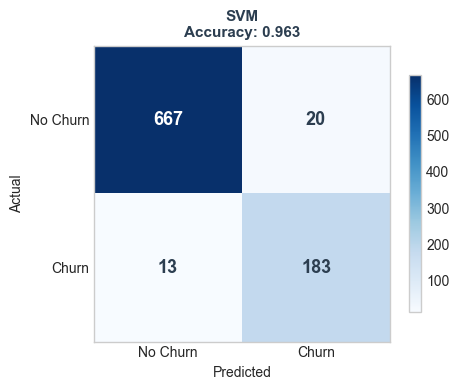

In [26]:
param_grid_svm = {'C': [0.1,1,10,100], 'kernel': ['rbf','linear'],
                   'gamma': ['scale','auto'], 'class_weight': ['balanced']}
grid_svm = GridSearchCV(SVC(random_state=42, probability=True),
                        param_grid_svm, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_svm.fit(X_train_resampled, y_train_resampled)

print(f"Best parameters : {grid_svm.best_params_}")
print(f"Best CV AUC-ROC : {grid_svm.best_score_:.4f}")
svm = grid_svm.best_estimator_
y_pred_svm, y_prob_svm = evaluate_model('SVM', svm,
                                         X_train_resampled, y_train_resampled, X_test, y_test)
fig, ax = plt.subplots(figsize=(5,4)); fig.patch.set_facecolor('white')
plot_cm(confusion_matrix(y_test, y_pred_svm), 'SVM',
        accuracy_score(y_test, y_pred_svm), ax)
plt.tight_layout()
plt.savefig('cm_svm.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## MODEL 7 — KNN

Best parameters : {'metric': 'manhattan', 'n_neighbors': 25, 'weights': 'uniform'}
Best CV AUC-ROC : 0.9775

Test Set Results :
Accuracy  : 0.9071
Precision : 0.7209
Recall    : 0.9490
F1-Score  : 0.8194
AUC-ROC   : 0.9809

Overfitting Check :
  Train AUC : 0.9850
  Test  AUC : 0.9809
  Gap       : 0.0040 ✅ No overfitting


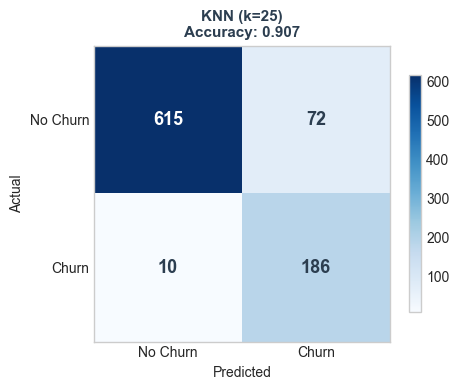

In [27]:
param_grid_knn = {'n_neighbors': [25,31,41,51,61,75],
                   'weights': ['uniform'],
                   'metric': ['euclidean','manhattan']}
grid_knn = GridSearchCV(KNeighborsClassifier(),
                        param_grid_knn, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_knn.fit(X_train_resampled, y_train_resampled)

print(f"Best parameters : {grid_knn.best_params_}")
print(f"Best CV AUC-ROC : {grid_knn.best_score_:.4f}")
knn = grid_knn.best_estimator_
y_pred_knn, y_prob_knn = evaluate_model('KNN', knn,
                                         X_train_resampled, y_train_resampled, X_test, y_test)
fig, ax = plt.subplots(figsize=(5,4)); fig.patch.set_facecolor('white')
plot_cm(confusion_matrix(y_test, y_pred_knn),
        f'KNN (k={grid_knn.best_params_["n_neighbors"]})',
        accuracy_score(y_test, y_pred_knn), ax)
plt.tight_layout()
plt.savefig('cm_knn.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## MODEL 8 — NAIVE BAYES

Best parameters : {'var_smoothing': 1e-06}
Best CV AUC-ROC : 0.8855

Test Set Results :
Accuracy  : 0.7429
Precision : 0.4617
Recall    : 0.9541
F1-Score  : 0.6223
AUC-ROC   : 0.9071

Overfitting Check :
  Train AUC : 0.8866
  Test  AUC : 0.9071
  Gap       : -0.0205 ✅ No overfitting


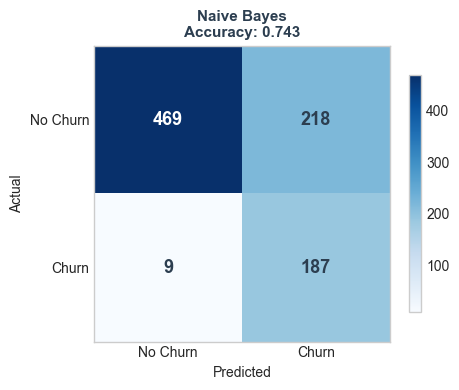

In [28]:
param_grid_nb = {'var_smoothing': [1e-9,1e-8,1e-7,1e-6,1e-5,1e-4]}
grid_nb = GridSearchCV(GaussianNB(), param_grid_nb, cv=cv, scoring='roc_auc', n_jobs=-1)
grid_nb.fit(X_train_resampled, y_train_resampled)

print(f"Best parameters : {grid_nb.best_params_}")
print(f"Best CV AUC-ROC : {grid_nb.best_score_:.4f}")
nb = grid_nb.best_estimator_
y_pred_nb, y_prob_nb = evaluate_model('Naive Bayes', nb,
                                       X_train_resampled, y_train_resampled, X_test, y_test)
fig, ax = plt.subplots(figsize=(5,4)); fig.patch.set_facecolor('white')
plot_cm(confusion_matrix(y_test, y_pred_nb), 'Naive Bayes',
        accuracy_score(y_test, y_pred_nb), ax)
plt.tight_layout()
plt.savefig('cm_naive_bayes.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()

## ALL CONFUSION MATRICES IN ONE FIGURE

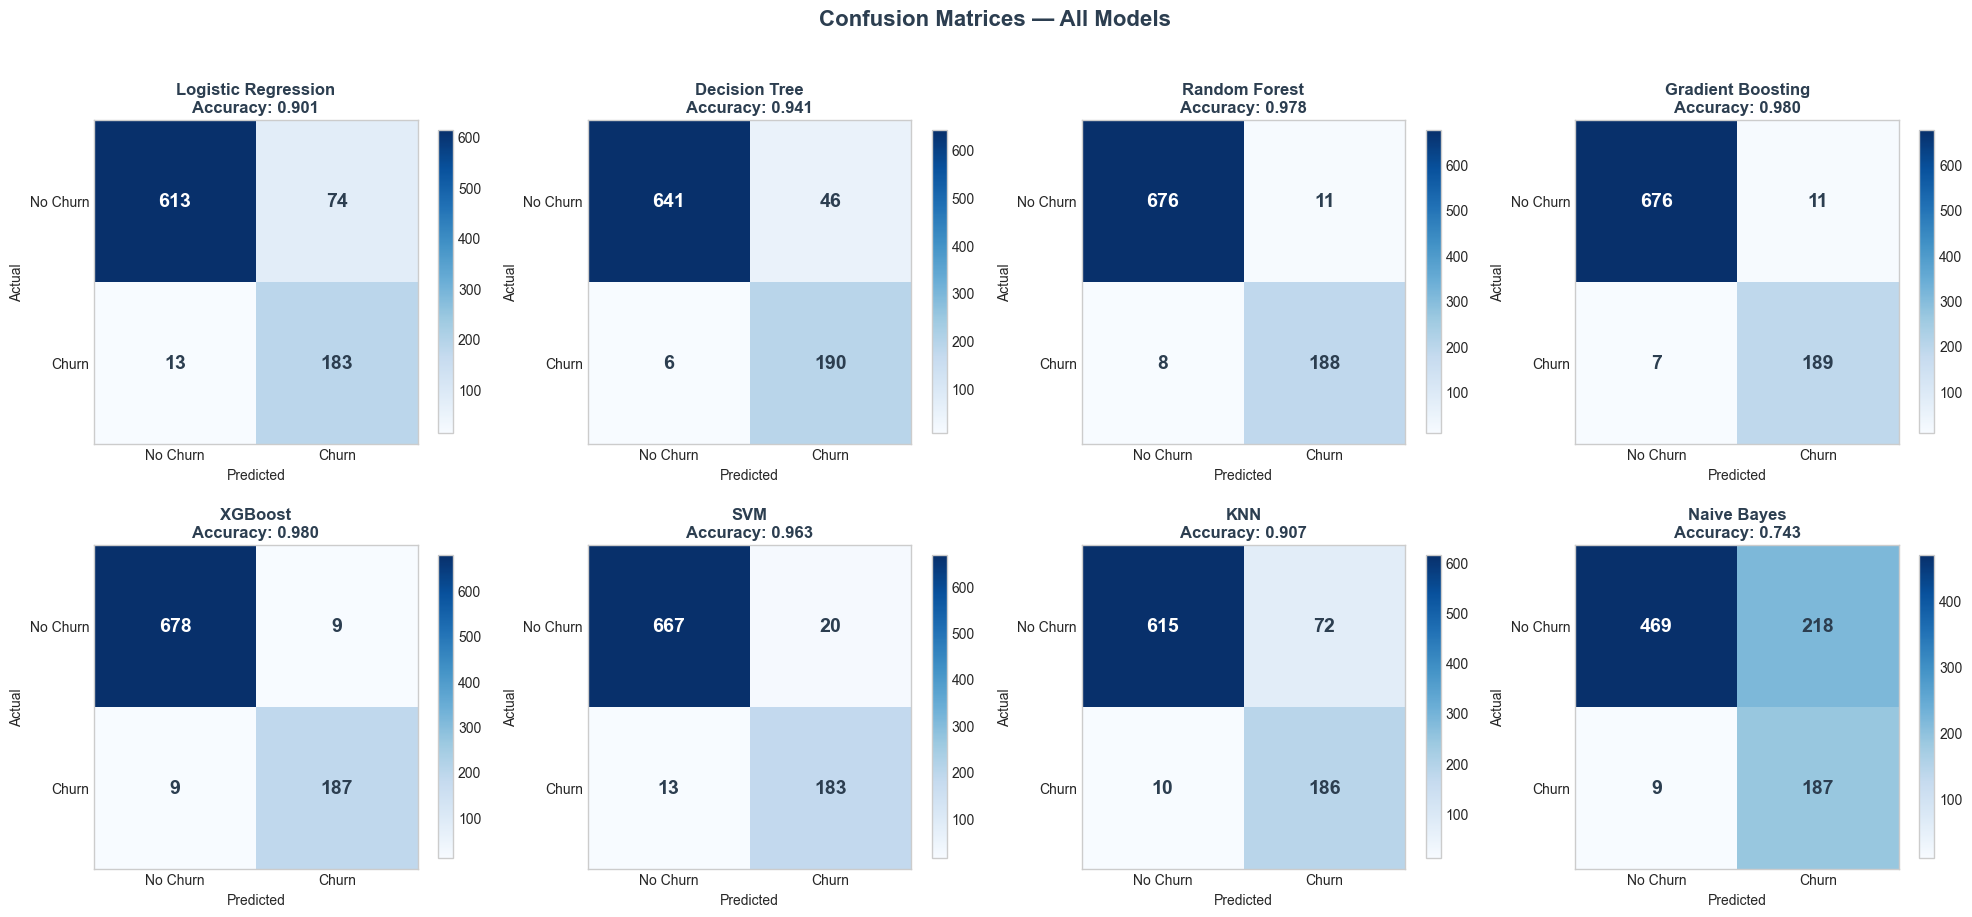

✅ Figure saved : all_confusion_matrices.png


In [32]:
models_preds = {
    'Logistic Regression': (y_pred_lr, y_prob_lr),
    'Decision Tree': (y_pred_dt, y_prob_dt),
    'Random Forest': (y_pred_rf, y_prob_rf),
    'Gradient Boosting': (y_pred_gb, y_prob_gb),
    'XGBoost': (y_pred_xgb, y_prob_xgb),
    'SVM': (y_pred_svm, y_prob_svm),
    'KNN': (y_pred_knn, y_prob_knn),
    'Naive Bayes': (y_pred_nb, y_prob_nb),
}

n_models = len(models_preds)
n_cols = 4
n_rows = (n_models + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols*5, n_rows*4.5))
fig.patch.set_facecolor('white')
axes = axes.flatten()

for i, (name, (y_pred, _)) in enumerate(models_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    acc = accuracy_score(y_test, y_pred)
    plot_confusion_matrix_pro(cm, name, acc, axes[i])

# Hide unused subplots
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models',
             fontsize=16, fontweight='bold',
             color=COLORS['primary'], y=1.02)
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Figure saved : all_confusion_matrices.png")

## PERFORMANCE COMPARISON TABLE

In [ ]:
models_results = {
    'Logistic Regression': {
        'Accuracy': accuracy_score(y_test, y_pred_lr),
        'Precision': precision_score(y_test, y_pred_lr),
        'Recall': recall_score(y_test, y_pred_lr),
        'F1-Score': f1_score(y_test, y_pred_lr),
        'AUC-ROC': roc_auc_score(y_test, y_prob_lr)
    },
    'Decision Tree': {
        'Accuracy': accuracy_score(y_test, y_pred_dt),
        'Precision': precision_score(y_test, y_pred_dt),
        'Recall': recall_score(y_test, y_pred_dt),
        'F1-Score': f1_score(y_test, y_pred_dt),
        'AUC-ROC': roc_auc_score(y_test, y_prob_dt)
    },
    'Random Forest': {
        'Accuracy': accuracy_score(y_test, y_pred_rf),
        'Precision': precision_score(y_test, y_pred_rf),
        'Recall': recall_score(y_test, y_pred_rf),
        'F1-Score': f1_score(y_test, y_pred_rf),
        'AUC-ROC': roc_auc_score(y_test, y_prob_rf)
    },
    'Gradient Boosting': {
        'Accuracy': accuracy_score(y_test, y_pred_gb),
        'Precision': precision_score(y_test, y_pred_gb),
        'Recall': recall_score(y_test, y_pred_gb),
        'F1-Score': f1_score(y_test, y_pred_gb),
        'AUC-ROC': roc_auc_score(y_test, y_prob_gb)
    },
    'XGBoost': {
        'Accuracy': accuracy_score(y_test, y_pred_xgb),
        'Precision': precision_score(y_test, y_pred_xgb),
        'Recall': recall_score(y_test, y_pred_xgb),
        'F1-Score': f1_score(y_test, y_pred_xgb),
        'AUC-ROC': roc_auc_score(y_test, y_prob_xgb)
    },
    'SVM': {
        'Accuracy': accuracy_score(y_test, y_pred_svm),
        'Precision': precision_score(y_test, y_pred_svm),
        'Recall': recall_score(y_test, y_pred_svm),
        'F1-Score': f1_score(y_test, y_pred_svm),
        'AUC-ROC': roc_auc_score(y_test, y_prob_svm)
    },
    'KNN': {
        'Accuracy': accuracy_score(y_test, y_pred_knn),
        'Precision': precision_score(y_test, y_pred_knn),
        'Recall': recall_score(y_test, y_pred_knn),
        'F1-Score': f1_score(y_test, y_pred_knn),
        'AUC-ROC': roc_auc_score(y_test, y_prob_knn)
    },
    'Naive Bayes': {
        'Accuracy': accuracy_score(y_test, y_pred_nb),
        'Precision': precision_score(y_test, y_pred_nb),
        'Recall': recall_score(y_test, y_pred_nb),
        'F1-Score': f1_score(y_test, y_pred_nb),
        'AUC-ROC': roc_auc_score(y_test, y_prob_nb)
    }
}

results_df = pd.DataFrame(models_results).T.round(4)
results_df = results_df.sort_values('AUC-ROC', ascending=False)
print(results_df.to_string())

                     Accuracy  Precision  Recall  F1-Score  AUC-ROC
Random Forest          0.9785     0.9447  0.9592    0.9519   0.9974
XGBoost                0.9796     0.9541  0.9541    0.9541   0.9968
Gradient Boosting      0.9796     0.9450  0.9643    0.9545   0.9965
SVM                    0.9626     0.9015  0.9337    0.9173   0.9868
Decision Tree          0.9411     0.8051  0.9694    0.8796   0.9843
KNN                    0.9071     0.7209  0.9490    0.8194   0.9809
Logistic Regression    0.9015     0.7121  0.9337    0.8079   0.9791
Naive Bayes            0.7429     0.4617  0.9541    0.6223   0.9071


# COMPARISON VISUALIZATION

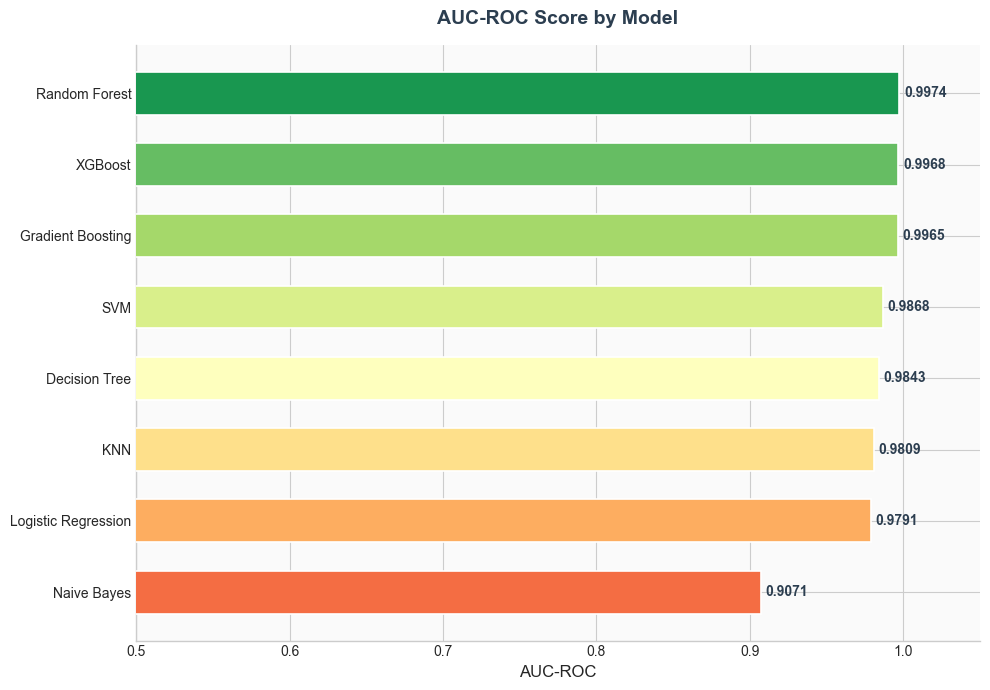

✅ auc_roc_ranking.png saved


In [ ]:
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('white')

colors_m = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(results_df)))
bars = ax.barh(results_df.index[::-1], results_df['AUC_ROC'][::-1],
               color=colors_m, edgecolor='white', linewidth=1.2,
               height=0.6, zorder=3)

ax.set_title('AUC-ROC Score by Model', fontsize=14, fontweight='bold',
             color=COLORS['primary'], pad=15)
ax.set_xlabel('AUC-ROC', fontsize=12)
ax.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlim(0.5, 1.05)

for bar, val in zip(bars, results_df['AUC_ROC'][::-1]):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10, fontweight='bold',
            color=COLORS['primary'])

plt.tight_layout()
plt.savefig('auc_roc_ranking.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ auc_roc_ranking.png saved")

## ROC CURVES — ALL MODELS

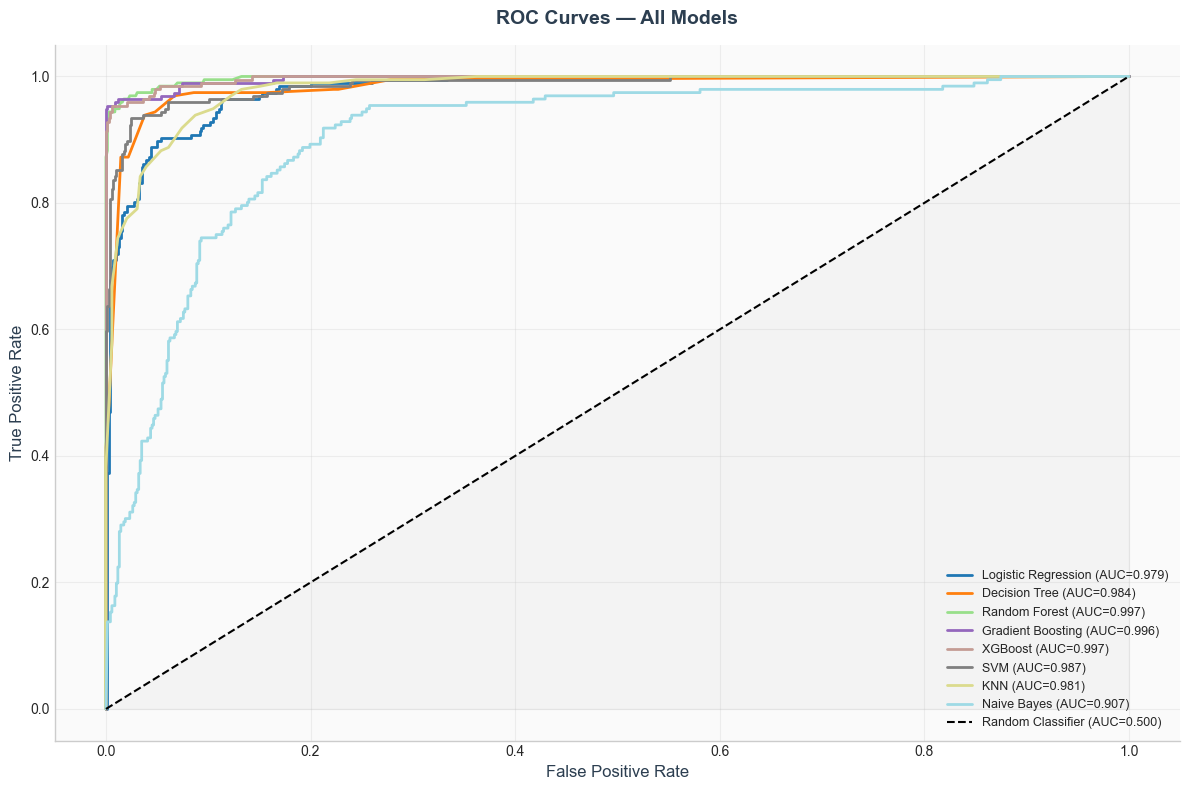

✅ Figure saved : roc_curves.png


In [37]:
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor('white')

y_probs_all = {
    'Logistic Regression': y_prob_lr,
    'Decision Tree': y_prob_dt,
    'Random Forest': y_prob_rf,
    'Gradient Boosting': y_prob_gb,
    'XGBoost': y_prob_xgb,
    'SVM': y_prob_svm,
    'KNN': y_prob_knn,
    'Naive Bayes': y_prob_nb
}

colors_roc = plt.cm.tab20(np.linspace(0, 1, len(y_probs_all)))

for (model, y_prob), color in zip(y_probs_all.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    ax.plot(fpr, tpr, label=f'{model} (AUC={auc:.3f})',
            color=color, linewidth=2)

ax.plot([0,1], [0,1], 'k--', linewidth=1.5,
        label='Random Classifier (AUC=0.500)')
ax.fill_between([0,1], [0,1], alpha=0.05, color='gray')
ax.set_title('ROC Curves — All Models',
             fontsize=14, fontweight='bold',
             color=COLORS['primary'], pad=15)
ax.set_xlabel('False Positive Rate', fontsize=12, color=COLORS['primary'])
ax.set_ylabel('True Positive Rate', fontsize=12, color=COLORS['primary'])
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('roc_curves.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Figure saved : roc_curves.png")

## CROSS VALIDATION — ALL MODELS

In [ ]:
models_cv = {
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Gradient Boosting': gb,
    'XGBoost': xgb,
    'SVM': svm,
    'KNN': knn,
    'Naive Bayes': nb
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_val_score(model, X_train_resampled, y_train_resampled,
                              cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name:25s} — Mean: {scores.mean():.4f} (+/- {scores.std():.4f})")

Logistic Regression       — Mean: 0.9710 (+/- 0.0049)
Decision Tree             — Mean: 0.9840 (+/- 0.0050)
Random Forest             — Mean: 0.9983 (+/- 0.0004)
Gradient Boosting         — Mean: 0.9988 (+/- 0.0002)
XGBoost                   — Mean: 0.9986 (+/- 0.0003)
SVM                       — Mean: 0.9915 (+/- 0.0017)
KNN                       — Mean: 0.9775 (+/- 0.0037)
Naive Bayes               — Mean: 0.8855 (+/- 0.0154)


## FEATURE IMPORTANCE ANAlYSIS
### 1/- GRADIENT BOOSTING (Best Model)

                     Feature  Importance
                   RFM_Score    0.574753
       Revenue_Evolution_Pct    0.157994
                Nb_Blockages    0.140361
     Avg_Days_Between_Orders    0.030124
            Total_Revenue_DA    0.027591
     Client_Seniority_Months    0.016566
             Avg_Order_Lines    0.011866
             Regularity_Rate    0.011764
      Avg_Payment_Delay_Days    0.006740
             Frequency_Total    0.006411
        Nb_Distinct_Products    0.005192
Nb_Cancelled_Returned_Orders    0.004286
      Outstanding_Balance_DA    0.003813
               Discount_Rate    0.002420
          Pre_Litigation_Enc    0.000114


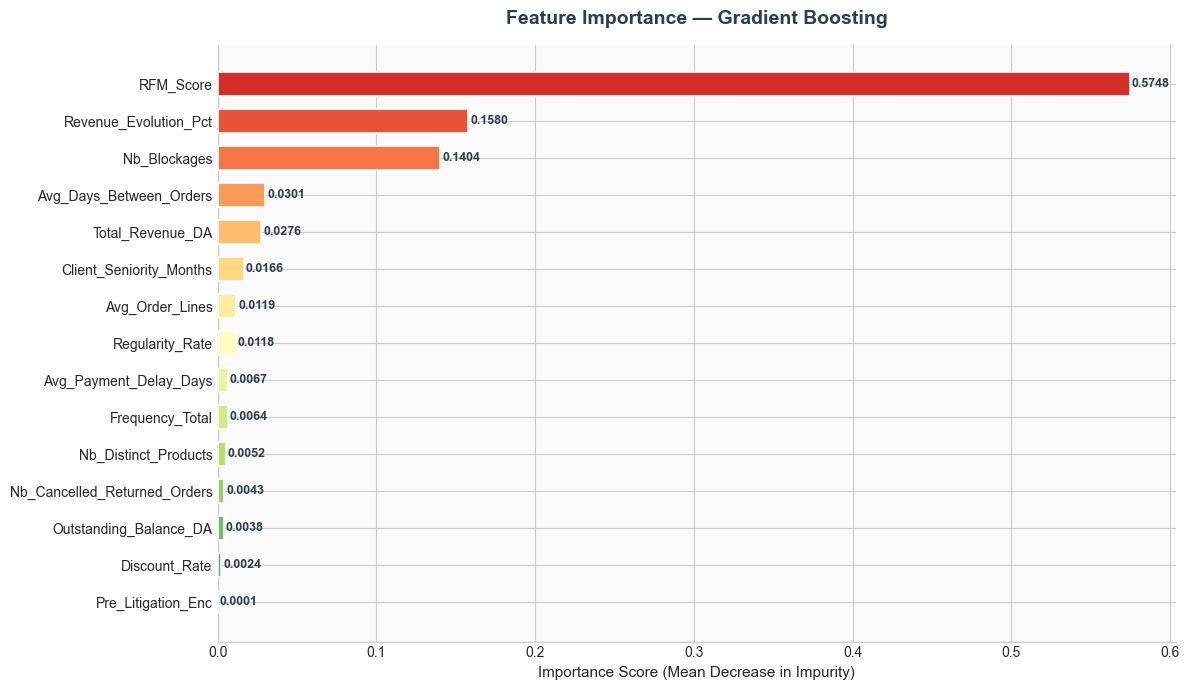

✅ Figure saved : feature_importance_rf.png


In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
warnings.filterwarnings('ignore')

# Get feature importances from Random Forest
feature_names  = X_test.columns.tolist()
importances_gb = gb.feature_importances_
indices_gb    = np.argsort(importances_rf)[::-1]

# Build dataframe
fi_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Importance' : importances_gb
}).sort_values('Importance', ascending=False).reset_index(drop=True)

print(fi_df.head(15).to_string(index=False))

# ── Plot Top 15 ───────────────────────────────────────────
plt.close('all')
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor('white')

top15 = fi_df.head(15)
colors_fi = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, 15))

bars = ax.barh(
    top15['Feature'][::-1],
    top15['Importance'][::-1],
    color=colors_fi,
    edgecolor='white', linewidth=1.2,
    height=0.65, zorder=3
)

for bar, val in zip(bars, top15['Importance'][::-1]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9,
            fontweight='bold', color=COLORS['primary'])

ax.set_title('Feature Importance — Gradient Boosting',
             fontsize=14, fontweight='bold',
             color=COLORS['primary'], pad=15)
ax.set_xlabel('Importance Score (Mean Decrease in Impurity)', fontsize=11)
ax.set_facecolor('#FAFAFA')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Figure saved : feature_importance_rf.png")

### 2/- GRADIENT BOOSTING vs XGBOOST

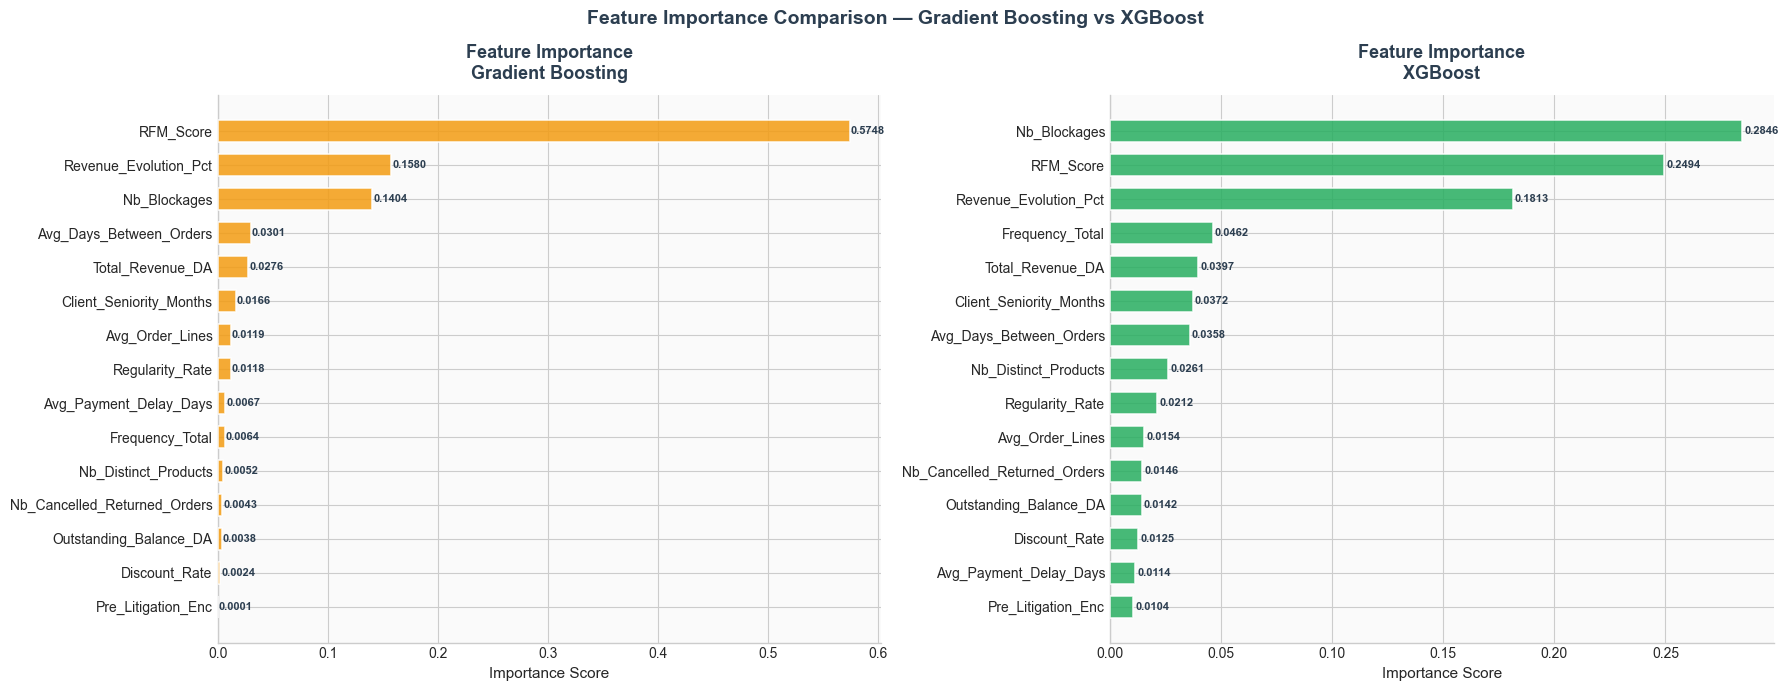

✅ Figure saved : feature_importance_gb_vs_xgb.png


In [ ]:
fi_xgb_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Importance' : xgb_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

plt.close('all')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.patch.set_facecolor('white')

for ax, fi_data, title, color in zip(
    axes,
    [fi_gb_df.head(15), fi_xgb_df.head(15)],
    ['Gradient Boosting', 'XGBoost'],
    [COLORS['gold'], COLORS['accent']]
):
    top = fi_data.head(15)
    bars = ax.barh(
        top['Feature'][::-1],
        top['Importance'][::-1],
        color=color, alpha=0.85,
        edgecolor='white', linewidth=1.2,
        height=0.65, zorder=3
    )
    for bar, val in zip(bars, top['Importance'][::-1]):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=8,
                fontweight='bold', color=COLORS['primary'])
    ax.set_title(f'Feature Importance\n{title}',
                 fontsize=13, fontweight='bold',
                 color=COLORS['primary'], pad=12)
    ax.set_xlabel('Importance Score', fontsize=11)
    ax.set_facecolor('#FAFAFA')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Feature Importance Comparison — Gradient Boosting vs XGBoost',
             fontsize=14, fontweight='bold',
             color=COLORS['primary'])
plt.tight_layout()
plt.savefig('feature_importance_gb_vs_xgb.png', dpi=200,
            bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Figure saved : feature_importance_gb_vs_xgb.png")

In [14]:
# Save final dataset to CSV
df.to_csv("hydrapharm_final_dataset.csv", index=False, encoding="utf-8")

print("✅ Dataset exported successfully as hydrapharm_final_dataset.csv")

✅ Dataset exported successfully as hydrapharm_final_dataset.csv


In [ ]:
# Save model, scaler and feature names
import joblib, json
joblib.dump(gb, 'gradient_boosting_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
with open('feature_names.json', 'w') as f:
    json.dump(X_train_resampled.columns.tolist(), f)